In [ ]:
# 处理和画图行为数据
import pandas as pd
import glob
import ast
from ast import literal_eval
import os
import numpy as np
from supply import *


#获取所有文件的地址
behavior_path = "E:/workspace/study2_escape_task_eeg/behavior/" # 分析哪个roi就输入哪个文件夹的数据


In [ ]:
# 处理和画图行为数据
import pandas as pd
import glob
import ast
from ast import literal_eval
import os
import numpy as np
from supply import *

import sys
sys.path.insert(0, 'E:/workspace/my_py_toolbox/') 
from hm_tools import *
## EEG
#获取所有文件的地址
behavior_path = "E:/workspace/study2_escape_task_eeg/behavior/" # 分析哪个roi就输入哪个文件夹的数据
# # behavior_folder = 'E:/workspace/study2_escape_task_seeg/behavior/134/'

all_sub_behavior_result = pd.DataFrame([])
for iter_subject in subjects:

    behavior_folder = behavior_path + str(iter_subject) + '/'
    trial_dict = pd.read_csv(behavior_folder + '/subject.csv')
    # 
    ## 先提取step数据进行分析，结果并入trial的数据

    # 先提取出step的数据，同时自动标记每个step在第几个stage中，最后返回的是一个用trial数检索的
    all_escaped_steps = import_step_data(list(trial_dict['trial_number']), behavior_folder)

    # 提取所有trial stage3和4的方向向量，返回一个列表的列表，空的地方就是空集
    dv_stage_1 = get_specific_datalist(all_escaped_steps, extract_column='direction_vector', mark_column='stage', 
                                                mark_value=[1])
    dv_stage_2 = get_specific_datalist(all_escaped_steps, extract_column='direction_vector', mark_column='stage', 
                                                mark_value=[2])
    dv_stage_3 = get_specific_datalist(all_escaped_steps, extract_column='direction_vector', mark_column='stage', 
                                                mark_value=[3])
    dv_stage_4 = get_specific_datalist(all_escaped_steps, extract_column='direction_vector', mark_column='stage', 
                                                mark_value=[4])
    dv_stage_5 = get_specific_datalist(all_escaped_steps, extract_column='direction_vector', mark_column='stage', 
                                                mark_value=[5])
    trial_dict['dv_stage_1'] = dv_stage_1
    trial_dict['dv_stage_2'] = dv_stage_2
    trial_dict['dv_stage_3'] = dv_stage_3
    trial_dict['dv_stage_4'] = dv_stage_4
    trial_dict['dv_stage_5'] = dv_stage_5

    # 提取所有trial stage 3,4,5 所有的时间
    time_stage_1 = get_specific_datalist(all_escaped_steps, extract_column='relative_time_from_begin', mark_column='stage', 
                                                mark_value=[1])
    time_stage_2 = get_specific_datalist(all_escaped_steps, extract_column='relative_time_from_begin', mark_column='stage', 
                                                mark_value=[2])
    time_stage_3 = get_specific_datalist(all_escaped_steps, extract_column='relative_time_from_begin', mark_column='stage', 
                                                mark_value=[3])
    time_stage_4 = get_specific_datalist(all_escaped_steps, extract_column='relative_time_from_begin', mark_column='stage', 
                                                mark_value=[4])
    time_stage_5 = get_specific_datalist(all_escaped_steps, extract_column='relative_time_from_begin', mark_column='stage', 
                                                mark_value=[5])
    trial_dict['time_stage_1'] = time_stage_1
    trial_dict['time_stage_2'] = time_stage_2
    trial_dict['time_stage_3'] = time_stage_3
    trial_dict['time_stage_4'] = time_stage_4
    trial_dict['time_stage_5'] = time_stage_5

    # 提取所有trial stage 3,4,5 开始的时间
    trial_dict['firsttime_stage_2'] = get_specific_firstdata(all_escaped_steps, extract_column='relative_time_from_begin', mark_column='stage', 
                                                mark_value=[2])
    trial_dict['firsttime_stage_3'] = get_specific_firstdata(all_escaped_steps, extract_column='relative_time_from_begin', mark_column='stage', 
                                                mark_value=[3])
    trial_dict['firsttime_stage_4'] = get_specific_firstdata(all_escaped_steps, extract_column='relative_time_from_begin', mark_column='stage', 
                                                mark_value=[4])
    trial_dict['firsttime_stage_5'] = get_specific_firstdata(all_escaped_steps, extract_column='relative_time_from_begin', mark_column='stage', 
                                                mark_value=[5])


    # 提取被试所有trial stage2, 3, 4, 5的轨迹
    traj_stage_2 = get_specific_datalist(all_escaped_steps, extract_column='circle_position', mark_column='stage', mark_value=[2])
    traj_stage_3 = get_specific_datalist(all_escaped_steps, extract_column='circle_position', mark_column='stage', mark_value=[3])
    traj_stage_4 = get_specific_datalist(all_escaped_steps, extract_column='circle_position', mark_column='stage', mark_value=[4])
    traj_stage_5 = get_specific_datalist(all_escaped_steps, extract_column='circle_position', mark_column='stage', mark_value=[5])
    traj_stage_345 = get_specific_datalist(all_escaped_steps, extract_column='circle_position', mark_column='stage', mark_value=[3,4,5])
    traj_stage_12345 = get_specific_datalist(all_escaped_steps, extract_column='circle_position', mark_column='stage', mark_value=[1,2,3,4,5])

    trial_dict['traj_stage_2'] = traj_stage_2
    trial_dict['traj_stage_3'] = traj_stage_3
    trial_dict['traj_stage_4'] = traj_stage_4
    trial_dict['traj_stage_5'] = traj_stage_5
    trial_dict['traj_stage_345'] = traj_stage_345
    trial_dict['traj_stage_12345'] = traj_stage_12345

    # 计算不同阶段的平均方向向量
    trial_dict['mean_dv_stage2'] = average_list_of_list(dv_stage_2)
    trial_dict['mean_dv_stage3'] = average_list_of_list(dv_stage_3)
    trial_dict['mean_dv_stage4'] = average_list_of_list(dv_stage_4)
    trial_dict['mean_dv_stage5'] = average_list_of_list(dv_stage_5)

    # 计算逃跑行为的反应时
    trial_dict['rt_point_stage3'], trial_dict['rt_stage3'] = find_consecutive_escape_time_of_list(dv_stage_3, time_stage_3, 20)

    # 提取捕食者所有trial stage 3, 4, 5的轨迹
    traj_p_stage_3 = get_specific_datalist(all_escaped_steps, extract_column='triangle_position', mark_column='stage', mark_value=[3])
    traj_p_stage_4 = get_specific_datalist(all_escaped_steps, extract_column='triangle_position', mark_column='stage', mark_value=[4])
    traj_p_stage_34 = get_specific_datalist(all_escaped_steps, extract_column='triangle_position', mark_column='stage', mark_value=[3,4])

    trial_dict['traj_p_stage_3'] = traj_p_stage_3
    trial_dict['traj_p_stage_4'] = traj_p_stage_4
    trial_dict['traj_p_stage_345'] = traj_p_stage_34

    # 计算从stage3开始的瞬间，捕食者与被试之间的距离
    trial_dict['s_p_distance_stage_3'] = calculate_distance(traj_stage_3, traj_p_stage_3)
    trial_dict['s_p_distance_stage_4'] = calculate_distance(traj_stage_4, traj_p_stage_4)
    trial_dict['s_p_distance_stage_345'] = calculate_distance(traj_stage_345, traj_p_stage_34)

    # 计算刚出现时的距离
    trial_dict['s_p_first_distance_stage_3'] = first_distance(trial_dict['s_p_distance_stage_3'])
    trial_dict['s_p_first_distance_stage_4'] = first_distance(trial_dict['s_p_distance_stage_4'])
    trial_dict['s_p_first_distance_stage_345'] = first_distance(trial_dict['s_p_distance_stage_345'])

    # 保存数据
    trial_dict.to_excel(behavior_folder + '/subject_v3.xlsx')

    # 计算总时间
    # 保存在trial的文件中

    # 分为高难度和低难度和无捕食者
    ############################# 分三类 #############################

    no_p_dict = trial_dict[trial_dict['event_num'].isin([11, 12])]

    high_p_dict = trial_dict[trial_dict['event_num'].isin([21,22,23])]

    low_p_dict = trial_dict[trial_dict['event_num'].isin([31,32])]

    # 创建存储计算出来的行为指标的dict

    behavior_result = pd.DataFrame([])

    trial_result_dict = trial_dict
    ############################# 先计算各种trial level的行为指标 #############################


    ## 低危险
    # 区分逃跑成功与否
    low_p_safe_dict = low_p_dict[low_p_dict['get_safe'] == 1]
    low_p_captured_dict = low_p_dict[low_p_dict['get_caught'] == 1]

    # 逃跑成功的概率
    low_p_safe_rate = len(low_p_safe_dict)/len(low_p_dict)
    behavior_result['low_p_safe_rate'] = [low_p_safe_rate]

    
    # 安全的trial中获得奖励的数量
    low_p_safe_mean_get_reward = 5-np.mean(low_p_safe_dict['remain_square'])
    low_p_mean_get_reward = 5-np.mean(low_p_dict['remain_square'])
    behavior_result['low_p_avg_get_reward'] = [low_p_mean_get_reward]
    behavior_result['low_p_safeavg_get_reward'] = [low_p_safe_mean_get_reward]

    # 安全的trial中吃完奖励的概率
    low_p_get_all_reward_rate = len(low_p_dict[low_p_dict['remain_square'] == 0])/len(low_p_dict)
    behavior_result['low_p_get_all_reward_rate'] = [low_p_get_all_reward_rate]

    # 捕食者进入追击状态的概率
    low_p_pursuit_rate = np.mean(low_p_dict['triangle_pursuit'])
    behavior_result['low_p_pursuit_rate'] = [low_p_pursuit_rate]

    # 捕食者出现时的敌我距离 low_p_dict['traj_stage_5'].apply(len) > 0
    s_p_first_distance_stage_3_list = list(low_p_dict['s_p_first_distance_stage_3'])
    s_p_first_distance_stage_3_list = [item for item in s_p_first_distance_stage_3_list if isinstance(item, (int, float))]


    behavior_result['low_p_pp_distance'] = np.mean(s_p_first_distance_stage_3_list)


    # 慢攻击下安全的trial中出现stage5的trial列表，概率
    low_p_safe_dict_stage5 = low_p_safe_dict[~low_p_safe_dict['time_stage_5'].apply(lambda x: len(x) == 0)]
    behavior_result['low_p_safe_stage5_rate'] = len(low_p_safe_dict_stage5)/len(low_p_safe_dict)

    ## 高危险
    # 区分逃跑成功与否
    high_p_safe_dict = high_p_dict[high_p_dict['get_safe'] == 1]
    high_p_captured_dict = high_p_dict[high_p_dict['get_caught'] == 1]

    # 逃跑成功的概率
    high_p_safe_rate = len(high_p_safe_dict)/len(high_p_dict)
    behavior_result['high_p_safe_rate'] = [high_p_safe_rate]

    # 安全的trial中获得奖励的数量
    high_p_safe_mean_get_reward = 5-np.mean(high_p_safe_dict['remain_square'])
    high_p_mean_get_reward = 5-np.mean(high_p_dict['remain_square'])
    behavior_result['high_p_avg_get_reward'] = [high_p_mean_get_reward]
    behavior_result['high_p_safeavg_get_reward'] = [high_p_safe_mean_get_reward]

    # 安全的trial中吃完奖励的概率
    high_p_get_all_reward_rate = len(high_p_dict[high_p_dict['remain_square'] == 0])/len(high_p_dict)
    behavior_result['high_p_get_all_reward_rate'] = [high_p_get_all_reward_rate]

    # 捕食者进入追击状态（进入状态4）的概率
    high_p_pursuit_rate = np.mean(high_p_dict['triangle_pursuit'])
    behavior_result['high_p_pursuit_rate'] = [high_p_pursuit_rate]

    # 捕食者出现时的敌我距离
    s_p_first_distance_stage_3_list = list(high_p_dict['s_p_first_distance_stage_3'])
    s_p_first_distance_stage_3_list = [item for item in s_p_first_distance_stage_3_list if isinstance(item, (int, float))]

    behavior_result['high_p_pp_distance'] = np.mean(s_p_first_distance_stage_3_list)
    ############################# 再计算 trajectory level的被试水平指标 #############################

    ## 低危险
    # 平均方向向量,stage 3, 包括所有和safe的
    behavior_result['low_mean_dv_stage3'] = [np.mean(low_p_dict['mean_dv_stage3'])]
    behavior_result['low_safe_mean_dv_stage3'] = [np.mean(low_p_safe_dict['mean_dv_stage3'])]
    # stage 4
    low_p_dict_stage4 = low_p_dict.dropna(subset=['mean_dv_stage4'])
    behavior_result['low_mean_dv_stage4'] = [np.mean(low_p_dict_stage4['mean_dv_stage4'])]

    # 威胁出现时躲避的平均反应时
    low_p_dict_ra = low_p_dict.dropna(subset=['rt_stage3'])
    behavior_result['low_mean_rt_stage3'] = [np.mean(low_p_dict_ra['rt_stage3'])]

    # 低危险时成功进入stage5的概率
    low_p_dict_stage5 = low_p_dict[low_p_dict['traj_stage_5'].apply(len) > 0]  # 躲避捕食者的试次
    behavior_result['low_stage5_rate'] = [len(low_p_dict_stage5)/len(low_p_dict)]

    ## 高危险
    # 平均方向向量,stage 3,包括所有和safe的
    behavior_result['high_mean_dv_stage3'] = [np.mean(high_p_dict['mean_dv_stage3'])]
    behavior_result['high_safe_mean_dv_stage3'] = [np.mean(high_p_safe_dict['mean_dv_stage3'])]

    # stage 4
    high_p_dict_stage4 = high_p_dict.dropna(subset=['mean_dv_stage4'])
    behavior_result['high_mean_dv_stage4'] = [np.mean(high_p_dict_stage4['mean_dv_stage4'])]

    # 威胁出现时躲避的平均反应时
    high_p_dict_ra = high_p_dict.dropna(subset=['rt_stage3'])
    behavior_result['high_mean_rt_stage3'] = [np.mean(high_p_dict_ra['rt_stage3'])]

    behavior_result['subjects'] = iter_subject

    all_sub_behavior_result = pd.concat([all_sub_behavior_result, behavior_result], sort=True)

# print(all_sub_behavior_result)


In [4]:
# 补充添加反应时情况  v3-v4
import pandas as pd
import glob
import ast
from ast import literal_eval
import os
import numpy as np
from supply import *

import sys
sys.path.insert(0, 'E:/workspace/my_py_toolbox/') 
from hm_tools import *
## EEG
#获取所有文件的地址
behavior_path = "E:/workspace/study2_escape_task_eeg/behavior/" # 分析哪个roi就输入哪个文件夹的数据

subjects = [4, 5, 6, 8, 9, 11, 12, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,39,40,41,42,43,45,46,47,49,50,51,52] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少
 # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少
# subjects = [49,50,51] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少
# subjects = [52]
all_sub_behavior_result = pd.DataFrame([])
for iter_subject in subjects:

    behavior_folder = behavior_path + str(iter_subject) + '/'
    trial_dict = pd.read_excel(behavior_folder + '/subject_v3.xlsx')
    # 
    ## 先提取step数据进行分析，结果并入trial的数据

    # 先提取出step的数据，同时自动标记每个step在第几个stage中，最后返回的是一个用trial数检索的
    all_escaped_steps = import_step_data(list(trial_dict['trial_number']), behavior_folder)

    ############# 计算反应时
    # 提取所有trial stage3和4的方向向量，返回一个列表的列表，空的地方就是空集
    dv_stage_34 = get_specific_datalist(all_escaped_steps, extract_column='direction_vector', mark_column='stage', 
                                                mark_value=[3, 4])
    trial_dict['dv_stage_34'] = dv_stage_34
    # 提取所有trial stage 3,4,5 所有的时间
    time_stage_34 = get_specific_datalist(all_escaped_steps, extract_column='relative_time_from_begin', mark_column='stage', 
                                                mark_value=[3,4])
    trial_dict['time_stage_34'] = time_stage_34
    # 计算逃跑行为的反应时
    trial_dict['rt_point_stage34'], trial_dict['rt_stage34'] = find_consecutive_escape_time_of_list(dv_stage_34, time_stage_34, 20)

    traj_stage_5 = get_specific_datalist(all_escaped_steps, extract_column='circle_position', mark_column='stage', mark_value=[5])
    trial_dict['traj_stage_5'] = traj_stage_5


    ################ 计算方向相对向量

    # 提取被试所有trial stage2, 3, 4, 5的轨迹

    dv_stage_2 = get_specific_datalist(all_escaped_steps, extract_column='direction_vector', mark_column='stage', 
                                                mark_value=[2])
    dv_stage_3 = get_specific_datalist(all_escaped_steps, extract_column='direction_vector', mark_column='stage', 
                                                mark_value=[3])
    dv_stage_4 = get_specific_datalist(all_escaped_steps, extract_column='direction_vector', mark_column='stage', 
                                                mark_value=[4])
    dv_stage_5 = get_specific_datalist(all_escaped_steps, extract_column='direction_vector', mark_column='stage', 
                                                mark_value=[5])
    dv_stage_34 = get_specific_datalist(all_escaped_steps, extract_column='direction_vector', mark_column='stage', 
                                                mark_value=[3,4])
    
    # 提取被试所有trial stage2, 3, 4, 5的轨迹
    traj_stage_2 = get_specific_datalist(all_escaped_steps, extract_column='circle_position', mark_column='stage', mark_value=[2])
    traj_stage_3 = get_specific_datalist(all_escaped_steps, extract_column='circle_position', mark_column='stage', mark_value=[3])
    traj_stage_4 = get_specific_datalist(all_escaped_steps, extract_column='circle_position', mark_column='stage', mark_value=[4])
    traj_stage_34 = get_specific_datalist(all_escaped_steps, extract_column='circle_position', mark_column='stage', mark_value=[3,4])    
    traj_stage_2345 = get_specific_datalist(all_escaped_steps, extract_column='circle_position', mark_column='stage', mark_value=[2,3,4,5])
    
    traj_p_stage_3 = get_specific_datalist(all_escaped_steps, extract_column='triangle_position', mark_column='stage', mark_value=[3])
    traj_p_stage_4 = get_specific_datalist(all_escaped_steps, extract_column='triangle_position', mark_column='stage', mark_value=[4])
    traj_p_stage_34 = get_specific_datalist(all_escaped_steps, extract_column='triangle_position', mark_column='stage', mark_value=[3,4])

    vector_prey_predator3 = position_to_vector(traj_p_stage_3, traj_stage_3)
    vector_prey_predator4 = position_to_vector( traj_p_stage_4, traj_stage_4)
    vector_prey_predator34 = position_to_vector( traj_p_stage_34,traj_stage_34)

    # 计算静止时间
    trial_dict['stationary_ratio_stage_3'] = calculate_stationary_ratio_list(traj_stage_3)
    trial_dict['stationary_ratio_stage_4'] = calculate_stationary_ratio_list(traj_stage_4)

    # 计算不同阶段的平均方向向量
    trial_dict['pp_angle_stage3'] = calculate_angle(dv_stage_3, vector_prey_predator3)
    trial_dict['pp_angle_stage4'] = calculate_angle(dv_stage_4, vector_prey_predator4)
    trial_dict['pp_angle_stage34'] = calculate_angle(dv_stage_34, vector_prey_predator34)
    trial_dict['pp_angle_stage3_mean'] = average_list_of_list2(trial_dict['pp_angle_stage3'])
    trial_dict['pp_angle_stage4_mean'] = average_list_of_list2(trial_dict['pp_angle_stage4'])
    trial_dict['pp_angle_stage34_mean'] = average_list_of_list2(trial_dict['pp_angle_stage34'])
    # trial_dict['mean_dv_stage5'] = average_list_of_list(dv_stage_5)

    ################ 计算距离安全区的位置


    # 计算被试和安全区之间的距离
    trial_dict['s_safe_distance_stage_2'] = get_distance_to_safe(traj_stage_2)
    trial_dict['s_safe_distance_stage_3'] = get_distance_to_safe(traj_stage_3)
    # trial_dict['s_safe_distance_stage_4'] = get_distance_to_safe(traj_stage_4)
    trial_dict['s_safe_distance_stage_2345'] = get_distance_to_safe(traj_stage_2345)

    trial_dict['s_safe_first_distance_stage_3'] = first_distance(trial_dict['s_safe_distance_stage_3'])


    ################ 保存数据
    # trial_dict.to_excel(behavior_folder + '/subject_v4.xlsx')

    # 计算总时间
    # 保存在trial的文件中

    # 分为高难度和低难度和无捕食者
    ############################# 分三类 #############################

    no_p_dict = trial_dict[trial_dict['event_num'].isin([11, 12])]

    high_p_dict = trial_dict[trial_dict['event_num'].isin([21,22,23])]

    low_p_dict = trial_dict[trial_dict['event_num'].isin([31,32])]

    # 创建存储计算出来的行为指标的dict

    behavior_result = pd.DataFrame([])

    trial_result_dict = trial_dict
    ############################# 先计算各种trial level的行为指标 #############################


    ## 低危险
    # 区分逃跑成功与否
    low_p_safe_dict = low_p_dict[low_p_dict['get_safe'] == 1]
    low_p_captured_dict = low_p_dict[low_p_dict['get_caught'] == 1]

    # 逃跑成功的概率
    low_p_safe_rate = len(low_p_safe_dict)/len(low_p_dict)
    behavior_result['low_p_safe_rate'] = [low_p_safe_rate]

    
    # 安全的trial中获得奖励的数量
    low_p_safe_mean_get_reward = 5-np.mean(low_p_safe_dict['remain_square'])
    low_p_mean_get_reward = (np.sum(5-low_p_safe_dict['remain_square'])/len(low_p_dict))
    behavior_result['low_p_avg_get_reward'] = [low_p_mean_get_reward]
    behavior_result['low_p_safeavg_get_reward'] = [low_p_safe_mean_get_reward]

    # 安全的trial中吃完奖励的概率
    low_p_get_all_reward_rate = len(low_p_dict[low_p_dict['remain_square'] == 0])/len(low_p_dict)
    behavior_result['low_p_get_all_reward_rate'] = [low_p_get_all_reward_rate]

    # 捕食者进入追击状态的概率
    low_p_pursuit_rate = np.mean(low_p_dict['triangle_pursuit'])
    behavior_result['low_p_pursuit_rate'] = [low_p_pursuit_rate]

    # 慢攻击下安全的trial中出现stage5的trial列表，概率
    low_p_safe_dict_stage5 = low_p_safe_dict[~low_p_safe_dict['time_stage_5'].apply(lambda x: len(x) == 0)]
    behavior_result['low_p_safe_stage5_rate'] = len(low_p_safe_dict_stage5)/len(low_p_safe_dict)

    ## 高危险
    # 区分逃跑成功与否
    high_p_safe_dict = high_p_dict[high_p_dict['get_safe'] == 1]
    high_p_captured_dict = high_p_dict[high_p_dict['get_caught'] == 1]

    # 逃跑成功的概率
    high_p_safe_rate = len(high_p_safe_dict)/len(high_p_dict)
    behavior_result['high_p_safe_rate'] = [high_p_safe_rate]

    # 安全的trial中获得奖励的数量
    high_p_safe_mean_get_reward = 5-np.mean(high_p_safe_dict['remain_square'])
    high_p_mean_get_reward = (np.sum(5-high_p_safe_dict['remain_square'])/len(high_p_dict))
    behavior_result['high_p_avg_get_reward'] = [high_p_mean_get_reward]
    behavior_result['high_p_safeavg_get_reward'] = [high_p_safe_mean_get_reward]

    # 安全的trial中吃完奖励的概率
    high_p_get_all_reward_rate = len(high_p_dict[high_p_dict['remain_square'] == 0])/len(high_p_dict)
    behavior_result['high_p_get_all_reward_rate'] = [high_p_get_all_reward_rate]

    # 捕食者进入追击状态（进入状态4）的概率
    high_p_pursuit_rate = np.mean(high_p_dict['triangle_pursuit'])
    behavior_result['high_p_pursuit_rate'] = [high_p_pursuit_rate]


    ############################# 再计算 trajectory level的被试水平指标 #############################

    ## 低危险
    # 平均方向向量,stage 3, 包括所有和safe的
    behavior_result['low_mean_dv_stage3'] = [np.mean(low_p_dict['mean_dv_stage3'])]
    behavior_result['low_safe_mean_dv_stage3'] = [np.mean(low_p_safe_dict['mean_dv_stage3'])]
    # stage 4
    low_p_dict_stage4 = low_p_dict.copy().dropna(subset=['mean_dv_stage4'])
    behavior_result['low_mean_dv_stage4'] = [np.mean(low_p_dict_stage4['mean_dv_stage4'])]

    # 威胁出现时躲避的平均反应时
    low_p_dict_ra = low_p_dict.copy().dropna(subset=['rt_stage34'])
    behavior_result['low_mean_rt_stage34'] = [np.mean(low_p_dict_ra['rt_stage34'])]

    # 低危险时成功进入stage5的概率
    low_p_dict_stage5 = low_p_dict.copy()[low_p_dict['traj_stage_5'].apply(len) > 0]  # 躲避捕食者的试次
    behavior_result['low_stage5_rate'] = [len(low_p_dict_stage5)/len(low_p_dict)]

    # 捕食者出现时的敌我距离 low_p_dict['traj_stage_5'].apply(len) > 0
    s_p_first_distance_stage_3_list = list(low_p_dict['s_p_first_distance_stage_3'])
    s_p_first_distance_stage_3_list = [item for item in s_p_first_distance_stage_3_list if isinstance(item, (int, float))]

    behavior_result['low_p_pp_distance'] = np.mean(s_p_first_distance_stage_3_list)

    # 捕食者出现时离安全区的距离 trial_dict['s_safe_first_distance_stage_3']
    s_safe_first_distance_stage_3_list = list(low_p_dict['s_safe_first_distance_stage_3'])
    s_safe_first_distance_stage_3_list = [item for item in s_safe_first_distance_stage_3_list if isinstance(item, (int, float))]

    behavior_result['low_p_psafe_distance'] = np.mean(s_safe_first_distance_stage_3_list)

    # 平均角度
    behavior_result['low_pp_angle_stage3'] = np.nanmean(low_p_dict['pp_angle_stage3_mean'])
    behavior_result['low_pp_angle_stage4'] = np.nanmean(low_p_dict['pp_angle_stage4_mean'])

    # stage3转弯次数
    behavior_result['low_stationary_ratio_stage_3'] = np.nanmean(low_p_dict['stationary_ratio_stage_3'])
    behavior_result['low_stationary_ratio_stage_4'] = np.nanmean(low_p_dict['stationary_ratio_stage_4'])

    # 
    ## 高危险
    # 平均方向向量,stage 3,包括所有和safe的
    behavior_result['high_mean_dv_stage3'] = [np.mean(high_p_dict['mean_dv_stage3'])]
    behavior_result['high_safe_mean_dv_stage3'] = [np.mean(high_p_safe_dict['mean_dv_stage3'])]

    # stage 4
    high_p_dict_stage4 = high_p_dict.copy().dropna(subset=['mean_dv_stage4'])
    behavior_result['high_mean_dv_stage4'] = [np.mean(high_p_dict_stage4['mean_dv_stage4'])]

    # 威胁出现时躲避的平均反应时
    high_p_dict_ra = high_p_dict.copy().dropna(subset=['rt_stage34'])
    behavior_result['high_mean_rt_stage34'] = [np.mean(high_p_dict_ra['rt_stage34'])]

    # 捕食者出现时的敌我距离
    s_p_first_distance_stage_3_list = list(high_p_dict['s_p_first_distance_stage_3'])
    s_p_first_distance_stage_3_list = [item for item in s_p_first_distance_stage_3_list if isinstance(item, (int, float))]

    behavior_result['high_p_pp_distance'] = np.mean(s_p_first_distance_stage_3_list)

    # 捕食者出现时离安全区的距离 trial_dict['s_safe_first_distance_stage_3']
    s_safe_first_distance_stage_3_list = list(high_p_dict['s_safe_first_distance_stage_3'])
    s_safe_first_distance_stage_3_list = [item for item in s_safe_first_distance_stage_3_list if isinstance(item, (int, float))]

    behavior_result['high_p_psafe_distance'] = np.mean(s_safe_first_distance_stage_3_list)

    # 平均角度
    behavior_result['high_pp_angle_stage3'] = np.nanmean(high_p_dict['pp_angle_stage3_mean'])
    behavior_result['high_pp_angle_stage4'] = np.nanmean(high_p_dict['pp_angle_stage4_mean'])

    # stage3转弯次数
    behavior_result['high_stationary_ratio_stage_3'] = np.nanmean(high_p_dict['stationary_ratio_stage_3'])
    behavior_result['high_stationary_ratio_stage_4'] = np.nanmean(high_p_dict['stationary_ratio_stage_4'])



    # 放入被试名称
    behavior_result['subjects'] = iter_subject

    all_sub_behavior_result = pd.concat([all_sub_behavior_result, behavior_result], sort=True)

# print(all_sub_behavior_result)


e:\workspace\study2_escape_task_eeg\code\supply.py:221: RuntimeWarning: invalid value encountered in true_divide
  cos_theta = dot_products / (norms_A * norms_B)
e:\workspace\study2_escape_task_eeg\code\supply.py:116: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.array(mean_result)
<ipython-input-4-ce8df855ed61>:210: RuntimeWarning: Mean of empty slice
  behavior_result['low_pp_angle_stage4'] = np.nanmean(low_p_dict['pp_angle_stage4_mean'])
<ipython-input-4-ce8df855ed61>:214: RuntimeWarning: Mean of empty slice
  behavior_result['low_stationary_ratio_stage_4'] = np.nanmean(low_p_dict['stationary_ratio_stage_4'])
<ipython-input-4-ce8df855ed61>:244: RuntimeWarning: Mean of empty slice
  behavior_result['high_pp_angle_stage4'] = np.nanmean(high_p_dict['pp_angle

In [ ]:
# 补充添加捕食者出现时剩余的奖励数量  v4-v5
import pandas as pd
import glob
import ast
from ast import literal_eval
import os
import numpy as np
from supply import *

import sys
sys.path.insert(0, 'E:/workspace/my_py_toolbox/') 
from hm_tools import *
## EEG
#获取所有文件的地址
behavior_path = "E:/workspace/study2_escape_task_eeg/behavior/" # 分析哪个roi就输入哪个文件夹的数据

subjects = [4, 5, 6, 8, 9, 11, 12, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,39,40,41,42,43,45,46,47,49,50,51,52] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少
 # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少
# subjects = [49,50,51] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少
# subjects = [52]
all_sub_behavior_result = pd.DataFrame([])
for iter_subject in subjects:

    behavior_folder = behavior_path + str(iter_subject) + '/'
    trial_dict = pd.read_excel(behavior_folder + '/subject_v4.xlsx')
    # 
    ## 先提取step数据进行分析，结果并入trial的数据

    # 先提取出step的数据，同时自动标记每个step在第几个stage中，最后返回的是一个用trial数检索的
    all_escaped_steps = import_step_data(list(trial_dict['trial_number']), behavior_folder)

    ############# 提取剩余的reward数量
    # 提取所有trial stage3和4的方向向量，返回一个列表的列表，空的地方就是空集
    remain_square_num_stage3 = get_specific_datalist(all_escaped_steps, extract_column='remain_square_num', mark_column='stage', 
                                                mark_value=[3])
    trial_dict['remain_square_num_stage3_first'] = first_distance(remain_square_num_stage3)
    trial_dict['remain_square_num_stage3_first'] = trial_dict['remain_square_num_stage3_first'].apply(len)

    # print(trial_dict['remain_square_num_stage3_first'])


    # 提取被试所有trial stage2, 3, 4, 5的轨迹
    traj_stage_2 = get_specific_datalist(all_escaped_steps, extract_column='circle_position', mark_column='stage', mark_value=[2])
    traj_stage_3 = get_specific_datalist(all_escaped_steps, extract_column='circle_position', mark_column='stage', mark_value=[3])
    traj_stage_4 = get_specific_datalist(all_escaped_steps, extract_column='circle_position', mark_column='stage', mark_value=[4])
    traj_stage_34 = get_specific_datalist(all_escaped_steps, extract_column='circle_position', mark_column='stage', mark_value=[3,4])    
    traj_stage_2345 = get_specific_datalist(all_escaped_steps, extract_column='circle_position', mark_column='stage', mark_value=[2,3,4,5])
    
    traj_p_stage_3 = get_specific_datalist(all_escaped_steps, extract_column='triangle_position', mark_column='stage', mark_value=[3])
    traj_p_stage_4 = get_specific_datalist(all_escaped_steps, extract_column='triangle_position', mark_column='stage', mark_value=[4])
    traj_p_stage_34 = get_specific_datalist(all_escaped_steps, extract_column='triangle_position', mark_column='stage', mark_value=[3,4])

    vector_prey_predator3 = position_to_vector(traj_p_stage_3, traj_stage_3)
    vector_prey_predator4 = position_to_vector( traj_p_stage_4, traj_stage_4)
    vector_prey_predator34 = position_to_vector( traj_p_stage_34,traj_stage_34)

    # 计算静止时间
    trial_dict['stationary_ratio_stage_3'] = calculate_stationary_ratio_list(traj_stage_3)
    trial_dict['stationary_ratio_stage_4'] = calculate_stationary_ratio_list(traj_stage_4)




    ################ 保存数据
    trial_dict.to_excel(behavior_folder + '/subject_v5.xlsx')

    # 计算总时间
    # 保存在trial的文件中

    # 分为高难度和低难度和无捕食者
    ############################# 分三类 #############################

    no_p_dict = trial_dict[trial_dict['event_num'].isin([11, 12])]

    high_p_dict = trial_dict[trial_dict['event_num'].isin([21,22,23])]

    low_p_dict = trial_dict[trial_dict['event_num'].isin([31,32])]

    # 创建存储计算出来的行为指标的dict

    behavior_result = pd.DataFrame([])

    trial_result_dict = trial_dict
    ############################# 先计算各种trial level的行为指标 #############################


    ## 低危险
    # 区分逃跑成功与否
    low_p_safe_dict = low_p_dict[low_p_dict['get_safe'] == 1]
    low_p_captured_dict = low_p_dict[low_p_dict['get_caught'] == 1]

    # 逃跑成功的概率
    low_p_safe_rate = len(low_p_safe_dict)/len(low_p_dict)
    behavior_result['low_p_safe_rate'] = [low_p_safe_rate]

    
    # 安全的trial中获得奖励的数量
    low_p_safe_mean_get_reward = 5-np.mean(low_p_safe_dict['remain_square'])
    low_p_mean_get_reward = (np.sum(5-low_p_safe_dict['remain_square'])/len(low_p_dict))
    behavior_result['low_p_avg_get_reward'] = [low_p_mean_get_reward]
    behavior_result['low_p_safeavg_get_reward'] = [low_p_safe_mean_get_reward]

    # 安全的trial中吃完奖励的概率
    low_p_get_all_reward_rate = len(low_p_dict[low_p_dict['remain_square'] == 0])/len(low_p_dict)
    behavior_result['low_p_get_all_reward_rate'] = [low_p_get_all_reward_rate]

    # 捕食者进入追击状态的概率
    low_p_pursuit_rate = np.mean(low_p_dict['triangle_pursuit'])
    behavior_result['low_p_pursuit_rate'] = [low_p_pursuit_rate]

    # 慢攻击下安全的trial中出现stage5的trial列表，概率
    low_p_safe_dict_stage5 = low_p_safe_dict[~low_p_safe_dict['time_stage_5'].apply(lambda x: len(x) == 0)]
    behavior_result['low_p_safe_stage5_rate'] = len(low_p_safe_dict_stage5)/len(low_p_safe_dict)

    ## 高危险
    # 区分逃跑成功与否
    high_p_safe_dict = high_p_dict[high_p_dict['get_safe'] == 1]
    high_p_captured_dict = high_p_dict[high_p_dict['get_caught'] == 1]

    # 逃跑成功的概率
    high_p_safe_rate = len(high_p_safe_dict)/len(high_p_dict)
    behavior_result['high_p_safe_rate'] = [high_p_safe_rate]

    # 安全的trial中获得奖励的数量
    high_p_safe_mean_get_reward = 5-np.mean(high_p_safe_dict['remain_square'])
    high_p_mean_get_reward = (np.sum(5-high_p_safe_dict['remain_square'])/len(high_p_dict))
    behavior_result['high_p_avg_get_reward'] = [high_p_mean_get_reward]
    behavior_result['high_p_safeavg_get_reward'] = [high_p_safe_mean_get_reward]

    # 安全的trial中吃完奖励的概率
    high_p_get_all_reward_rate = len(high_p_dict[high_p_dict['remain_square'] == 0])/len(high_p_dict)
    behavior_result['high_p_get_all_reward_rate'] = [high_p_get_all_reward_rate]

    # 捕食者进入追击状态（进入状态4）的概率
    high_p_pursuit_rate = np.mean(high_p_dict['triangle_pursuit'])
    behavior_result['high_p_pursuit_rate'] = [high_p_pursuit_rate]


    ############################# 再计算 trajectory level的被试水平指标 #############################

    ## 低危险
    # 平均方向向量,stage 3, 包括所有和safe的
    behavior_result['low_mean_dv_stage3'] = [np.mean(low_p_dict['mean_dv_stage3'])]
    behavior_result['low_safe_mean_dv_stage3'] = [np.mean(low_p_safe_dict['mean_dv_stage3'])]
    # stage 4
    low_p_dict_stage4 = low_p_dict.copy().dropna(subset=['mean_dv_stage4'])
    behavior_result['low_mean_dv_stage4'] = [np.mean(low_p_dict_stage4['mean_dv_stage4'])]

    # 威胁出现时躲避的平均反应时
    low_p_dict_ra = low_p_dict.copy().dropna(subset=['rt_stage34'])
    behavior_result['low_mean_rt_stage34'] = [np.mean(low_p_dict_ra['rt_stage34'])]

    # 低危险时成功进入stage5的概率
    low_p_dict_stage5 = low_p_dict.copy()[low_p_dict['traj_stage_5'].apply(len) > 0]  # 躲避捕食者的试次
    behavior_result['low_stage5_rate'] = [len(low_p_dict_stage5)/len(low_p_dict)]

    # 捕食者出现时的敌我距离 low_p_dict['traj_stage_5'].apply(len) > 0
    s_p_first_distance_stage_3_list = list(low_p_dict['s_p_first_distance_stage_3'])
    s_p_first_distance_stage_3_list = [item for item in s_p_first_distance_stage_3_list if isinstance(item, (int, float))]

    behavior_result['low_p_pp_distance'] = np.mean(s_p_first_distance_stage_3_list)

    # 捕食者出现时离安全区的距离 trial_dict['s_safe_first_distance_stage_3']
    s_safe_first_distance_stage_3_list = list(low_p_dict['s_safe_first_distance_stage_3'])
    s_safe_first_distance_stage_3_list = [item for item in s_safe_first_distance_stage_3_list if isinstance(item, (int, float))]

    behavior_result['low_p_psafe_distance'] = np.mean(s_safe_first_distance_stage_3_list)

    # 平均角度
    behavior_result['low_pp_angle_stage3'] = np.nanmean(low_p_dict['pp_angle_stage3_mean'])
    behavior_result['low_pp_angle_stage4'] = np.nanmean(low_p_dict['pp_angle_stage4_mean'])

    # stage3转弯次数
    behavior_result['low_stationary_ratio_stage_3'] = np.nanmean(low_p_dict['stationary_ratio_stage_3'])
    behavior_result['low_stationary_ratio_stage_4'] = np.nanmean(low_p_dict['stationary_ratio_stage_4'])

    # 捕食者出现时剩余的奖励
    behavior_result['low_remain_reward_p_appear'] = np.nanmean(low_p_dict['remain_square_num_stage3_first'])
    # behavior_result['low_stationary_ratio_stage_4'] = np.nanmean(low_p_dict['stationary_ratio_stage_4'])

    # 
    ## 高危险
    # 平均方向向量,stage 3,包括所有和safe的
    behavior_result['high_mean_dv_stage3'] = [np.mean(high_p_dict['mean_dv_stage3'])]
    behavior_result['high_safe_mean_dv_stage3'] = [np.mean(high_p_safe_dict['mean_dv_stage3'])]

    # stage 4
    high_p_dict_stage4 = high_p_dict.copy().dropna(subset=['mean_dv_stage4'])
    behavior_result['high_mean_dv_stage4'] = [np.mean(high_p_dict_stage4['mean_dv_stage4'])]

    # 威胁出现时躲避的平均反应时
    high_p_dict_ra = high_p_dict.copy().dropna(subset=['rt_stage34'])
    behavior_result['high_mean_rt_stage34'] = [np.mean(high_p_dict_ra['rt_stage34'])]

    # 捕食者出现时的敌我距离
    s_p_first_distance_stage_3_list = list(high_p_dict['s_p_first_distance_stage_3'])
    s_p_first_distance_stage_3_list = [item for item in s_p_first_distance_stage_3_list if isinstance(item, (int, float))]

    behavior_result['high_p_pp_distance'] = np.mean(s_p_first_distance_stage_3_list)

    # 捕食者出现时离安全区的距离 trial_dict['s_safe_first_distance_stage_3']
    s_safe_first_distance_stage_3_list = list(high_p_dict['s_safe_first_distance_stage_3'])
    s_safe_first_distance_stage_3_list = [item for item in s_safe_first_distance_stage_3_list if isinstance(item, (int, float))]

    behavior_result['high_p_psafe_distance'] = np.mean(s_safe_first_distance_stage_3_list)

    # 平均角度
    behavior_result['high_pp_angle_stage3'] = np.nanmean(high_p_dict['pp_angle_stage3_mean'])
    behavior_result['high_pp_angle_stage4'] = np.nanmean(high_p_dict['pp_angle_stage4_mean'])

    # stage3转弯次数
    behavior_result['high_stationary_ratio_stage_3'] = np.nanmean(high_p_dict['stationary_ratio_stage_3'])
    behavior_result['high_stationary_ratio_stage_4'] = np.nanmean(high_p_dict['stationary_ratio_stage_4'])

    # 捕食者出现时剩余的奖励
    behavior_result['high_remain_reward_p_appear'] = np.nanmean(high_p_dict['remain_square_num_stage3_first'])


    # 放入被试名称
    behavior_result['subjects'] = iter_subject

    all_sub_behavior_result = pd.concat([all_sub_behavior_result, behavior_result], sort=True)

# print(all_sub_behavior_result)


0      2
1      3
2      2
3      4
4      2
      ..
115    2
116    0
117    0
118    3
119    2
Name: remain_square_num_stage3_first, Length: 120, dtype: int64


<ipython-input-12-2935a916e7e6>:172: RuntimeWarning: Mean of empty slice
  behavior_result['low_pp_angle_stage4'] = np.nanmean(low_p_dict['pp_angle_stage4_mean'])
<ipython-input-12-2935a916e7e6>:176: RuntimeWarning: Mean of empty slice
  behavior_result['low_stationary_ratio_stage_4'] = np.nanmean(low_p_dict['stationary_ratio_stage_4'])
<ipython-input-12-2935a916e7e6>:210: RuntimeWarning: Mean of empty slice
  behavior_result['high_pp_angle_stage4'] = np.nanmean(high_p_dict['pp_angle_stage4_mean'])
<ipython-input-12-2935a916e7e6>:214: RuntimeWarning: Mean of empty slice
  behavior_result['high_stationary_ratio_stage_4'] = np.nanmean(high_p_dict['stationary_ratio_stage_4'])


0      0
1      3
2      4
3      0
4      4
      ..
115    0
116    3
117    0
118    2
119    3
Name: remain_square_num_stage3_first, Length: 120, dtype: int64
0      2
1      4
2      1
3      4
4      4
      ..
113    3
114    2
115    4
116    1
117    0
Name: remain_square_num_stage3_first, Length: 118, dtype: int64
0      4
1      2
2      0
3      3
4      0
      ..
115    0
116    3
117    4
118    3
119    0
Name: remain_square_num_stage3_first, Length: 120, dtype: int64
0      0
1      0
2      2
3      4
4      4
      ..
115    2
116    3
117    0
118    0
119    2
Name: remain_square_num_stage3_first, Length: 120, dtype: int64
0      2
1      2
2      4
3      3
4      3
      ..
114    4
115    0
116    2
117    0
118    0
Name: remain_square_num_stage3_first, Length: 119, dtype: int64
0      4
1      0
2      3
3      4
4      1
      ..
114    2
115    2
116    0
117    0
118    0
Name: remain_square_num_stage3_first, Length: 119, dtype: int64
0      3
1      0
2   

<ipython-input-12-2935a916e7e6>:172: RuntimeWarning: Mean of empty slice
  behavior_result['low_pp_angle_stage4'] = np.nanmean(low_p_dict['pp_angle_stage4_mean'])
<ipython-input-12-2935a916e7e6>:176: RuntimeWarning: Mean of empty slice
  behavior_result['low_stationary_ratio_stage_4'] = np.nanmean(low_p_dict['stationary_ratio_stage_4'])


0      2
1      3
2      3
3      4
4      2
      ..
115    0
116    2
117    3
118    0
119    0
Name: remain_square_num_stage3_first, Length: 120, dtype: int64
0      3
1      0
2      3
3      0
4      0
      ..
115    4
116    0
117    1
118    2
119    3
Name: remain_square_num_stage3_first, Length: 120, dtype: int64
0      0
1      4
2      3
3      0
4      0
      ..
115    0
116    4
117    2
118    0
119    0
Name: remain_square_num_stage3_first, Length: 120, dtype: int64
0      0
1      4
2      0
3      0
4      3
      ..
112    2
113    0
114    0
115    2
116    2
Name: remain_square_num_stage3_first, Length: 117, dtype: int64
0      3
1      0
2      0
3      4
4      2
      ..
113    0
114    3
115    0
116    1
117    3
Name: remain_square_num_stage3_first, Length: 118, dtype: int64
0      2
1      0
2      0
3      2
4      2
      ..
114    2
115    0
116    3
117    3
118    4
Name: remain_square_num_stage3_first, Length: 119, dtype: int64
0      2
1      3
2   

: 

In [5]:
all_sub_behavior_result.to_excel(behavior_path + '/all_subjects.xlsx')

In [2]:
# 导入数据
import pandas as pd
import glob
import ast
from ast import literal_eval
import os
import numpy as np
from supply import *

import sys
sys.path.insert(0, 'E:/workspace/my_py_toolbox/') 
from hm_tools import *

#获取所有文件的地址
behavior_path = "E:/workspace/study2_escape_task_eeg/behavior/" # 分析哪个roi就输入哪个文件夹的数据

all_sub_behavior_result = pd.read_excel(behavior_path + '/all_subjects.xlsx')


In [4]:
# 高威胁和低危胁的逃跑率
# all_sub_behavior_result['high_p_safe_rate']
# all_sub_behavior_result['low_p_safe_rate']

print('高威胁和低危胁的逃跑率,高, 低')
# high_p_safe_dict_ra = high_p_dict.dropna(subset=['rt_stage3'])
# low_p_safe_dict_ra = low_p_dict.dropna(subset=['rt_stage3'])
print(np.mean(all_sub_behavior_result['high_p_safe_rate']), np.mean(all_sub_behavior_result['low_p_safe_rate']), hm_t_test_rel(all_sub_behavior_result['high_p_safe_rate'],all_sub_behavior_result['low_p_safe_rate']))
print(np.std(all_sub_behavior_result['high_p_safe_rate']), np.std(all_sub_behavior_result['low_p_safe_rate']))

print('高威胁和低危胁吃的平均奖励,高, 低')
# all_sub_behavior_result['low_p_avg_get_reward'] 
# all_sub_behavior_result['high_p_avg_get_reward'] 
print(np.mean(all_sub_behavior_result['high_p_avg_get_reward']), np.mean(all_sub_behavior_result['low_p_avg_get_reward']), hm_t_test_rel(all_sub_behavior_result['high_p_avg_get_reward'],all_sub_behavior_result['low_p_avg_get_reward']))
print(np.std(all_sub_behavior_result['high_p_avg_get_reward']), np.std(all_sub_behavior_result['low_p_avg_get_reward']))

print('高威胁和低危胁进入stage4的概率,高, 低')
# all_sub_behavior_result['low_p_pursuit_rate'] 
# all_sub_behavior_result['high_p_pursuit_rate'] 
print(np.mean(all_sub_behavior_result['high_p_pursuit_rate']), np.mean(all_sub_behavior_result['low_p_pursuit_rate']), hm_t_test_rel(all_sub_behavior_result['high_p_pursuit_rate'],all_sub_behavior_result['low_p_pursuit_rate']))
print(np.std(all_sub_behavior_result['high_p_pursuit_rate']), np.std(all_sub_behavior_result['low_p_pursuit_rate']))

print('高威胁和低危胁时stage3被试移动平均向量,高, 低')
# all_sub_behavior_result['high_mean_dv_stage3'] 
# all_sub_behavior_result['low_mean_dv_stage3'] 
print(np.mean(all_sub_behavior_result['high_mean_dv_stage3']), np.mean(all_sub_behavior_result['low_mean_dv_stage3']), hm_t_test_rel(all_sub_behavior_result['high_mean_dv_stage3'],all_sub_behavior_result['low_mean_dv_stage3']))
print(np.std(all_sub_behavior_result['high_mean_dv_stage3']), np.std(all_sub_behavior_result['low_mean_dv_stage3']))


all_sub_behavior_result_nostage4 = all_sub_behavior_result.dropna(subset=['low_mean_dv_stage4'])
all_sub_behavior_result_nostage4 = all_sub_behavior_result_nostage4.iloc[:6].append(all_sub_behavior_result_nostage4.iloc[7:])
print('高威胁和低危胁时stage4被试移动平均向量,高, 低')
# all_sub_behavior_result['high_mean_dv_stage4'] 
# all_sub_behavior_result['low_mean_dv_stage4'] 
print(np.mean(all_sub_behavior_result_nostage4['high_mean_dv_stage4']), np.mean(all_sub_behavior_result_nostage4['low_mean_dv_stage4']), hm_t_test_rel(all_sub_behavior_result_nostage4['high_mean_dv_stage4'],all_sub_behavior_result_nostage4['low_mean_dv_stage4']))
print(np.std(all_sub_behavior_result['high_mean_dv_stage4']), np.std(all_sub_behavior_result['low_mean_dv_stage4']))

print('stage3和4的Direct-diver的差别')
# all_sub_behavior_result['high_mean_dv_stage4'] 
# all_sub_behavior_result['low_mean_dv_stage4'] 
print(np.mean(all_sub_behavior_result_nostage4['high_mean_dv_stage4']-all_sub_behavior_result_nostage4['low_mean_dv_stage4']), np.mean(all_sub_behavior_result_nostage4['high_mean_dv_stage3']-all_sub_behavior_result_nostage4['low_mean_dv_stage3']), 
      hm_t_test_rel(all_sub_behavior_result_nostage4['high_mean_dv_stage4']-all_sub_behavior_result_nostage4['low_mean_dv_stage4'],all_sub_behavior_result_nostage4['high_mean_dv_stage3']-all_sub_behavior_result_nostage4['low_mean_dv_stage3']))
print(np.std(all_sub_behavior_result['high_mean_dv_stage4']), np.std(all_sub_behavior_result['low_mean_dv_stage4']))


print('低危胁时stage3和stage4对比被试移动平均向量,3, 4')
# all_sub_behavior_result['high_mean_dv_stage3'] 
# all_sub_behavior_result['low_mean_dv_stage3'] 
print(np.mean(all_sub_behavior_result_nostage4['low_mean_dv_stage3']), np.mean(all_sub_behavior_result_nostage4['low_mean_dv_stage4']), hm_t_test(all_sub_behavior_result_nostage4['low_mean_dv_stage3'],all_sub_behavior_result_nostage4['low_mean_dv_stage4']))
print(np.std(all_sub_behavior_result_nostage4['low_mean_dv_stage3']), np.std(all_sub_behavior_result_nostage4['low_mean_dv_stage4']))

print('高威胁时stage3和stage4被试移动平均向量,3, 4')
# all_sub_behavior_result['high_mean_dv_stage4'] 
# all_sub_behavior_result['low_mean_dv_stage4'] 
print(np.mean(all_sub_behavior_result_nostage4['high_mean_dv_stage3']), np.mean(all_sub_behavior_result_nostage4['high_mean_dv_stage4']), hm_t_test_rel(all_sub_behavior_result_nostage4['high_mean_dv_stage3'],all_sub_behavior_result_nostage4['high_mean_dv_stage4']))

print('高威胁和低危胁时stage3被试的平均反应时,高, 低')
# all_sub_behavior_result['high_mean_dv_stage3'] 
# all_sub_behavior_result['low_mean_dv_stage3'] 
print(np.mean(all_sub_behavior_result['high_mean_rt_stage34']), np.mean(all_sub_behavior_result['low_mean_rt_stage34']), hm_t_test_rel(all_sub_behavior_result['high_mean_rt_stage34'],all_sub_behavior_result['low_mean_rt_stage34']))
print(np.std(all_sub_behavior_result['high_mean_rt_stage34']), np.std(all_sub_behavior_result['low_mean_rt_stage34']))

print('高威胁和低危胁时stage3敌我距离,高, 低')
# all_sub_behavior_result['high_mean_dv_stage3'] 
# all_sub_behavior_result['low_mean_dv_stage3'] 
print(np.mean(all_sub_behavior_result['high_p_psafe_distance']), np.mean(all_sub_behavior_result['low_p_psafe_distance']), hm_t_test_rel(all_sub_behavior_result['high_p_psafe_distance'],all_sub_behavior_result['low_p_psafe_distance']))
print(np.std(all_sub_behavior_result['high_p_psafe_distance']), np.std(all_sub_behavior_result['low_p_psafe_distance']))

print('高威胁和低危胁时stage3被试freeze的时间占比')
# all_sub_behavior_result['high_mean_dv_stage3'] 
# all_sub_behavior_result['low_mean_dv_stage3'] 
print(np.mean(all_sub_behavior_result['high_stationary_ratio_stage_3']), np.mean(all_sub_behavior_result['low_stationary_ratio_stage_3']), hm_t_test_rel(all_sub_behavior_result['high_stationary_ratio_stage_3'],all_sub_behavior_result['low_stationary_ratio_stage_3']))
print(np.std(all_sub_behavior_result['high_stationary_ratio_stage_3']), np.std(all_sub_behavior_result['low_stationary_ratio_stage_3']))

print('低危胁时stage3和stage4 freeze的时间占比,3, 4')
# all_sub_behavior_result['high_mean_dv_stage3'] 
# all_sub_behavior_result['low_mean_dv_stage3'] 
print(np.mean(all_sub_behavior_result_nostage4['low_stationary_ratio_stage_3']), np.mean(all_sub_behavior_result_nostage4['low_stationary_ratio_stage_4']), hm_t_test(all_sub_behavior_result_nostage4['low_stationary_ratio_stage_3'],all_sub_behavior_result_nostage4['low_stationary_ratio_stage_4']))
print(np.std(all_sub_behavior_result_nostage4['low_stationary_ratio_stage_3']), np.std(all_sub_behavior_result_nostage4['low_stationary_ratio_stage_4']))

print('高威胁时stage3和stage4freeze的时间占比,3, 4')
# all_sub_behavior_result['high_mean_dv_stage4'] 
# all_sub_behavior_result['low_mean_dv_stage4'] 
print(np.mean(all_sub_behavior_result_nostage4['high_stationary_ratio_stage_3']), np.mean(all_sub_behavior_result_nostage4['high_stationary_ratio_stage_4']), hm_t_test_rel(all_sub_behavior_result_nostage4['high_stationary_ratio_stage_3'],all_sub_behavior_result_nostage4['high_stationary_ratio_stage_4']))


print('高威胁和低危胁时Distance to safe zone')
# all_sub_behavior_result['high_mean_dv_stage3'] 
# all_sub_behavior_result['low_mean_dv_stage3'] 
print(np.mean(all_sub_behavior_result['high_p_psafe_distance']), np.mean(all_sub_behavior_result['low_p_psafe_distance']), hm_t_test_rel(all_sub_behavior_result['high_p_psafe_distance'],all_sub_behavior_result['low_p_psafe_distance']))
print(np.std(all_sub_behavior_result['high_p_psafe_distance']), np.std(all_sub_behavior_result['low_p_psafe_distance']))



高威胁和低危胁的逃跑率,高, 低
0.725439399781505 0.8709401709401708 (-7.692672842666833, 1.765081403413842e-09, False)
0.14744186068645876 0.08598983452156722
高威胁和低危胁吃的平均奖励,高, 低
1.7049635306214252 4.339667277167277 (-43.807102047543424, 4.653848577730575e-36, False)
0.33617048590560944 0.4279501180554359
高威胁和低危胁进入stage4的概率,高, 低
0.3139989396568344 0.12905982905982907 (8.64953693941009, 8.656487536941925e-11, False)
0.17592817971502475 0.08598983452156722
高威胁和低危胁时stage3被试移动平均向量,高, 低
-0.4974170369107781 -0.09175708006781494 (-11.64583566160213, 1.3954915274162739e-14, False)
0.17987010744666096 0.0995852483938455
高威胁和低危胁时stage4被试移动平均向量,高, 低
-0.7951632815655397 -0.6764403421922057 (-4.058771498212262, 0.00023710756984620876, False)
0.10060905616455038 0.20469657252773102
stage3和4的Direct-diver的差别
-0.11872293937333406 -0.39724321763425713 (7.002097968246527, 2.4432771695100294e-08, False)
0.10060905616455038 0.20469657252773102
低危胁时stage3和stage4对比被试移动平均向量,3, 4
-0.08512517143861062 -0.6764403421922057 (19.

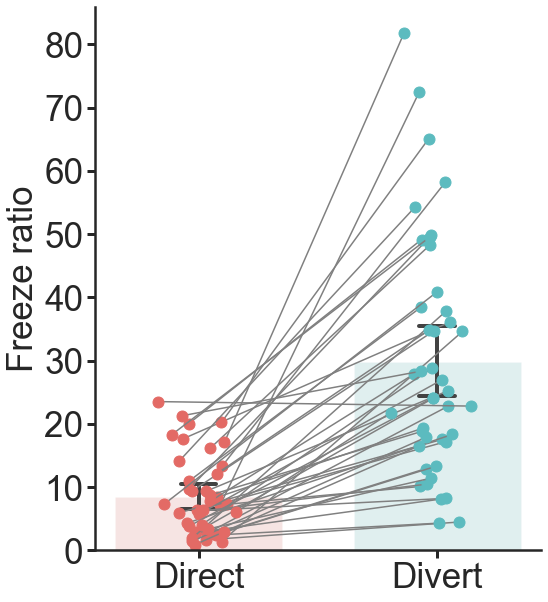

In [5]:
# 画所有被试的freeze时间占比
point_color = ['#E36A65', '#FF943C']
point_color = ['#E36A65','#5CBBBF']

all_data_df = {}
# all_data_df["Direct"] = list(-all_sub_behavior_result['high_mean_dv_stage3'])
# all_data_df["Divert"] = list(-all_sub_behavior_result['low_mean_dv_stage3'])

# 正确率
all_data_df["Direct"] = 100 * np.array(list(all_sub_behavior_result['high_stationary_ratio_stage_3']))
all_data_df["Divert"] = 100 * np.array(list(all_sub_behavior_result['low_stationary_ratio_stage_3']))

all_data_df = pd.DataFrame(all_data_df)

import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style("ticks"):

    plt.rcParams['figure.figsize'] = (8,10) # 设置figure_size尺寸

    # sns.boxplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#deefe8", "#f9e3d9"])
    # ['#E36A65','#FF943C'] 
    sns.barplot(data=all_data_df, palette=point_color, width=0.7,capsize=0.15, errwidth=4, alpha=0.2)
    # sns.stripplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#66c2a5", "#fc8d62"], size=4)
    # sns.stripplot(data=all_data_df, palette=["#E36A65", "#5CBBBF", "#f9e3d9"], size=10)    # violinplot plot

    # 在横轴上略微打乱一下点 （替代stripplot）
    jitter = 0.07
    df_x_jitter = pd.DataFrame(np.random.normal(loc=0, scale=jitter, size=all_data_df.values.shape), columns=all_data_df.columns)
    df_x_jitter += np.arange(len(all_data_df.columns))

    for i in range(len(all_data_df)):
        plt.plot([df_x_jitter["Direct"][i], df_x_jitter["Divert"][i]], [all_data_df["Direct"][i], all_data_df["Divert"][i]], color="grey")
        plt.plot(df_x_jitter["Direct"][i], all_data_df["Direct"][i], marker="o", color=point_color[0], markersize=11)
        plt.plot(df_x_jitter["Divert"][i], all_data_df["Divert"][i], marker="o", color=point_color[1], markersize=11)

    spines_width = 2.5
    ax=plt.gca()
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)
    sns.despine()
    ticksize = 35
    # plt.ylabel("Reaction time (s)", size=ticksize, fontproperties='Arial')
    plt.ylabel("Freeze ratio", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Average reward", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 3", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 4", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Distance between prey and predator", size=ticksize, fontproperties='Arial')

    ticksize = 35
    # 坐标的粗细
    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    # plt.ylim([0.8, 1.2])

    # 刻度的粗细
    plt.tick_params(axis='x', width=3, size=8)
    plt.tick_params(axis='y', width=3, size=8)
    # plt.tight_layout()
# plt.savefig(r'D:\Desktop\项目\seeg\画图\fc_new\vmpfc_amy\psi_amy_vmpfc.jpg',dpi=500, overwrite=True)


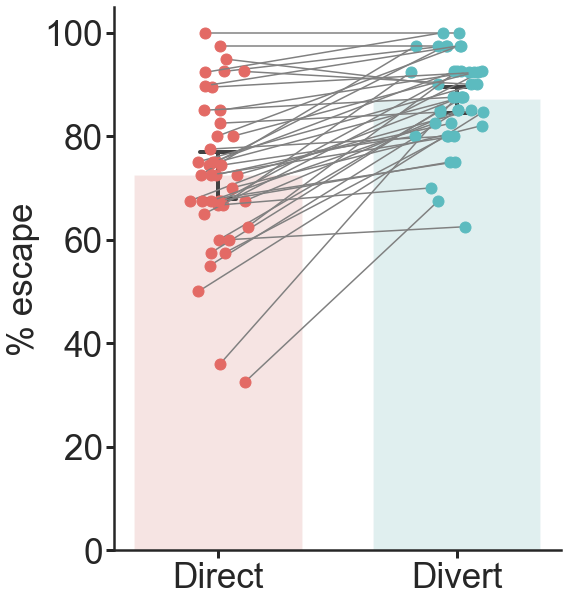

In [6]:
# 画所有被试的正确率 fast正确率，slow正确率，high_p_avg_get_reward
point_color = ['#E36A65', '#FF943C']
point_color = ['#E36A65','#5CBBBF']

all_data_df = {}
# all_data_df["Direct"] = list(-all_sub_behavior_result['high_mean_dv_stage3'])
# all_data_df["Divert"] = list(-all_sub_behavior_result['low_mean_dv_stage3'])

# 正确率
all_data_df["Direct"] = 100 * np.array(list(all_sub_behavior_result['high_p_safe_rate']))
all_data_df["Divert"] = 100 * np.array(list(all_sub_behavior_result['low_p_safe_rate']))

all_data_df = pd.DataFrame(all_data_df)

import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style("ticks"):

    plt.rcParams['figure.figsize'] = (8,10) # 设置figure_size尺寸

    # sns.boxplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#deefe8", "#f9e3d9"])
    # ['#E36A65','#FF943C'] 
    sns.barplot(data=all_data_df, palette=point_color, width=0.7,capsize=0.15, errwidth=4, alpha=0.2)
    # sns.stripplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#66c2a5", "#fc8d62"], size=4)
    # sns.stripplot(data=all_data_df, palette=["#E36A65", "#5CBBBF", "#f9e3d9"], size=10)    # violinplot plot

    # 在横轴上略微打乱一下点 （替代stripplot）
    jitter = 0.07
    df_x_jitter = pd.DataFrame(np.random.normal(loc=0, scale=jitter, size=all_data_df.values.shape), columns=all_data_df.columns)
    df_x_jitter += np.arange(len(all_data_df.columns))

    for i in range(len(all_data_df)):
        plt.plot([df_x_jitter["Direct"][i], df_x_jitter["Divert"][i]], [all_data_df["Direct"][i], all_data_df["Divert"][i]], color="grey")
        plt.plot(df_x_jitter["Direct"][i], all_data_df["Direct"][i], marker="o", color=point_color[0], markersize=11)
        plt.plot(df_x_jitter["Divert"][i], all_data_df["Divert"][i], marker="o", color=point_color[1], markersize=11)

    spines_width = 2.5
    ax=plt.gca()
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)
    sns.despine()
    ticksize = 35
    # plt.ylabel("Reaction time (s)", size=ticksize, fontproperties='Arial')
    plt.ylabel("% escape", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Average reward", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 3", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 4", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Distance between prey and predator", size=ticksize, fontproperties='Arial')

    ticksize = 35
    # 坐标的粗细
    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    # plt.ylim([0.8, 1.2])

    # 刻度的粗细
    plt.tick_params(axis='x', width=3, size=8)
    plt.tick_params(axis='y', width=3, size=8)
    # plt.tight_layout()
# plt.savefig(r'D:\Desktop\项目\seeg\画图\fc_new\vmpfc_amy\psi_amy_vmpfc.jpg',dpi=500, overwrite=True)


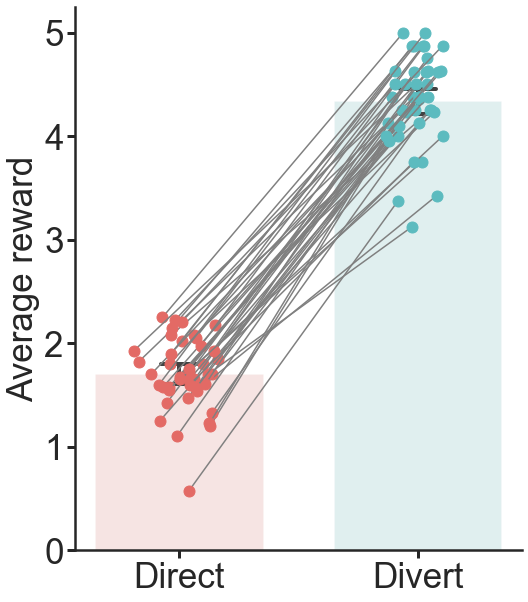

In [7]:
# 画所有被试的平均奖励
point_color = ['#E36A65', '#FF943C']
point_color = ['#E36A65','#5CBBBF']

all_data_df = {}
# all_data_df["Direct"] = list(-all_sub_behavior_result['high_mean_dv_stage3'])
# all_data_df["Divert"] = list(-all_sub_behavior_result['low_mean_dv_stage3'])

# 正确率
# all_data_df["Direct"] = list(all_sub_behavior_result['high_p_safe_rate'])
# all_data_df["Divert"] = list(all_sub_behavior_result['low_p_safe_rate'])
# 平均奖励
all_data_df["Direct"] = list(all_sub_behavior_result['high_p_avg_get_reward'])
all_data_df["Divert"] = list(all_sub_behavior_result['low_p_avg_get_reward'])
# 反应时
# all_data_df["Direct"] = list(all_sub_behavior_result['high_mean_rt_stage3'])
# all_data_df["Divert"] = list(all_sub_behavior_result['low_mean_rt_stage3'])
# stage 3时的移动向量
# all_data_df["Direct"] = list(-all_sub_behavior_result['high_mean_dv_stage3'])
# all_data_df["Divert"] = list(-all_sub_behavior_result['low_mean_dv_stage3'])
# stage 4时的移动向量
# all_data_df["Direct"] = list(-all_sub_behavior_result['high_mean_dv_stage4'])
# all_data_df["Divert"] = list(-all_sub_behavior_result['low_mean_dv_stage4'])

all_data_df = pd.DataFrame(all_data_df)

import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style("ticks"):

    plt.rcParams['figure.figsize'] = (8,10) # 设置figure_size尺寸

    # sns.boxplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#deefe8", "#f9e3d9"])
    # ['#E36A65','#FF943C'] 
    sns.barplot(data=all_data_df, palette=point_color, width=0.7,capsize=0.15, errwidth=4, alpha=0.2)
    # sns.stripplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#66c2a5", "#fc8d62"], size=4)
    # sns.stripplot(data=all_data_df, palette=["#E36A65", "#5CBBBF", "#f9e3d9"], size=10)    # violinplot plot
    
    # 在横轴上略微打乱一下点 （替代stripplot）
    jitter = 0.07
    df_x_jitter = pd.DataFrame(np.random.normal(loc=0, scale=jitter, size=all_data_df.values.shape), columns=all_data_df.columns)
    df_x_jitter += np.arange(len(all_data_df.columns))

    for i in range(len(all_data_df)):
        plt.plot([df_x_jitter["Direct"][i], df_x_jitter["Divert"][i]], [all_data_df["Direct"][i], all_data_df["Divert"][i]], color="grey")
        plt.plot(df_x_jitter["Direct"][i], all_data_df["Direct"][i], marker="o", color=point_color[0], markersize=11)
        plt.plot(df_x_jitter["Divert"][i], all_data_df["Divert"][i], marker="o", color=point_color[1], markersize=11)

    spines_width = 2.5
    ax=plt.gca()
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)
    sns.despine()
    ticksize = 35
    # plt.ylabel("Reaction time (s)", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape rate", size=ticksize, fontproperties='Arial')
    plt.ylabel("Average reward", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 3", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 4", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Distance between prey and predator", size=ticksize, fontproperties='Arial')

    ticksize = 35
    # 坐标的粗细
    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    # plt.ylim([0.8, 1.2])

    # 刻度的粗细
    plt.tick_params(axis='x', width=3, size=8)
    plt.tick_params(axis='y', width=3, size=8)
    # plt.tight_layout()
# plt.savefig(r'D:\Desktop\项目\seeg\画图\fc_new\vmpfc_amy\psi_amy_vmpfc.jpg',dpi=500, overwrite=True)


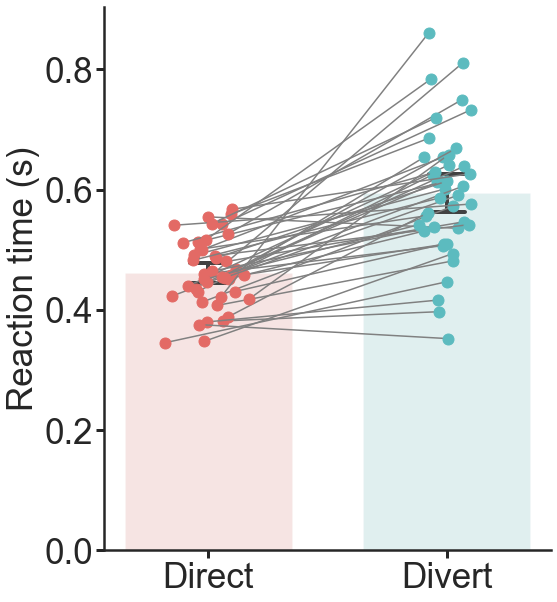

In [8]:
# 画所有被试反应时
point_color = ['#E36A65', '#FF943C']
point_color = ['#E36A65','#5CBBBF']

all_data_df = {}
# all_data_df["Direct"] = list(-all_sub_behavior_result['high_mean_dv_stage3'])
# all_data_df["Divert"] = list(-all_sub_behavior_result['low_mean_dv_stage3'])

# 正确率
# all_data_df["Direct"] = list(all_sub_behavior_result['high_p_safe_rate'])
# all_data_df["Divert"] = list(all_sub_behavior_result['low_p_safe_rate'])
# 平均奖励
# all_data_df["Direct"] = list(all_sub_behavior_result['high_p_avg_get_reward'])
# all_data_df["Divert"] = list(all_sub_behavior_result['low_p_avg_get_reward'])
# 反应时
all_data_df["Direct"] = list(all_sub_behavior_result['high_mean_rt_stage34'])
all_data_df["Divert"] = list(all_sub_behavior_result['low_mean_rt_stage34'])
# stage 3时的移动向量
# all_data_df["Direct"] = list(-all_sub_behavior_result['high_mean_dv_stage3'])
# all_data_df["Divert"] = list(-all_sub_behavior_result['low_mean_dv_stage3'])
# stage 4时的移动向量
# all_data_df["Direct"] = list(-all_sub_behavior_result['high_mean_dv_stage4'])
# all_data_df["Divert"] = list(-all_sub_behavior_result['low_mean_dv_stage4'])

all_data_df = pd.DataFrame(all_data_df)

import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style("ticks"):

    plt.rcParams['figure.figsize'] = (8,10) # 设置figure_size尺寸

    # sns.boxplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#deefe8", "#f9e3d9"])
    # ['#E36A65','#FF943C'] 
    sns.barplot(data=all_data_df, palette=point_color, width=0.7,capsize=0.15, errwidth=4, alpha=0.2)
    # sns.stripplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#66c2a5", "#fc8d62"], size=4)
    # sns.stripplot(data=all_data_df, palette=["#E36A65", "#5CBBBF", "#f9e3d9"], size=10)    # violinplot plot
    
    # 在横轴上略微打乱一下点 （替代stripplot）
    jitter = 0.07
    df_x_jitter = pd.DataFrame(np.random.normal(loc=0, scale=jitter, size=all_data_df.values.shape), columns=all_data_df.columns)
    df_x_jitter += np.arange(len(all_data_df.columns))

    for i in range(len(all_data_df)):
        plt.plot([df_x_jitter["Direct"][i], df_x_jitter["Divert"][i]], [all_data_df["Direct"][i], all_data_df["Divert"][i]], color="grey")
        plt.plot(df_x_jitter["Direct"][i], all_data_df["Direct"][i], marker="o", color=point_color[0], markersize=11)
        plt.plot(df_x_jitter["Divert"][i], all_data_df["Divert"][i], marker="o", color=point_color[1], markersize=11)

    spines_width = 2.5
    ax=plt.gca()
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)
    sns.despine()
    ticksize = 35
    plt.ylabel("Reaction time (s)", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape rate", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Average reward", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 3", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 4", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Distance between prey and predator", size=ticksize, fontproperties='Arial')

    ticksize = 35
    # 坐标的粗细
    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    # plt.ylim([0.8, 1.2])

    # 刻度的粗细
    plt.tick_params(axis='x', width=3, size=8)
    plt.tick_params(axis='y', width=3, size=8)
    # plt.tight_layout()
# plt.savefig(r'D:\Desktop\项目\seeg\画图\fc_new\vmpfc_amy\psi_amy_vmpfc.jpg',dpi=500, overwrite=True)


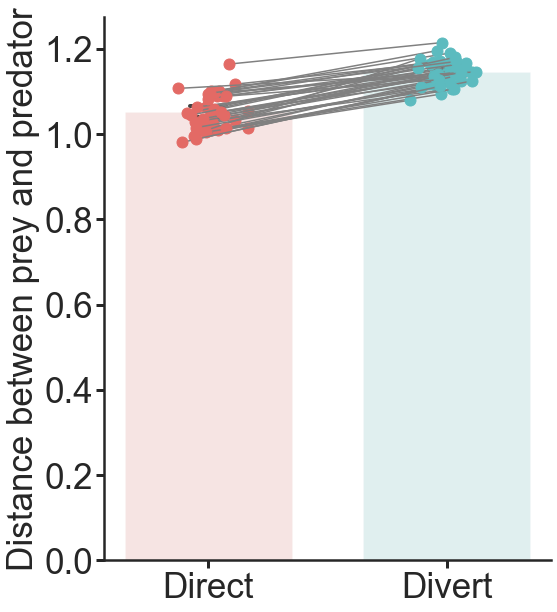

In [9]:
# 画所有被试的敌我距离
point_color = ['#E36A65', '#FF943C']
point_color = ['#E36A65','#5CBBBF']

all_data_df = {}
# all_data_df["Direct"] = list(-all_sub_behavior_result['high_mean_dv_stage3'])
# all_data_df["Divert"] = list(-all_sub_behavior_result['low_mean_dv_stage3'])

# 正确率
all_data_df["Direct"] = list(all_sub_behavior_result['high_p_pp_distance'])
all_data_df["Divert"] = list(all_sub_behavior_result['low_p_pp_distance'])
# 平均奖励
# all_data_df["Direct"] = list(all_sub_behavior_result['high_p_avg_get_reward'])
# all_data_df["Divert"] = list(all_sub_behavior_result['low_p_avg_get_reward'])
# 反应时
# all_data_df["Direct"] = list(all_sub_behavior_result['high_mean_rt_stage3'])
# all_data_df["Divert"] = list(all_sub_behavior_result['low_mean_rt_stage3'])
# stage 3时的移动向量
# all_data_df["Direct"] = list(-all_sub_behavior_result['high_mean_dv_stage3'])
# all_data_df["Divert"] = list(-all_sub_behavior_result['low_mean_dv_stage3'])
# stage 4时的移动向量
# all_data_df["Direct"] = list(-all_sub_behavior_result['high_mean_dv_stage4'])
# all_data_df["Divert"] = list(-all_sub_behavior_result['low_mean_dv_stage4'])

all_data_df = pd.DataFrame(all_data_df)

import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style("ticks"):

    plt.rcParams['figure.figsize'] = (8,10) # 设置figure_size尺寸

    # sns.boxplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#deefe8", "#f9e3d9"])
    # ['#E36A65','#FF943C'] 
    sns.barplot(data=all_data_df, palette=point_color, width=0.7,capsize=0.15, errwidth=4, alpha=0.2)
    # sns.stripplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#66c2a5", "#fc8d62"], size=4)
    # sns.stripplot(data=all_data_df, palette=["#E36A65", "#5CBBBF", "#f9e3d9"], size=10)    # violinplot plot
    
    # 在横轴上略微打乱一下点 （替代stripplot）
    jitter = 0.07
    df_x_jitter = pd.DataFrame(np.random.normal(loc=0, scale=jitter, size=all_data_df.values.shape), columns=all_data_df.columns)
    df_x_jitter += np.arange(len(all_data_df.columns))

    for i in range(len(all_data_df)):
        plt.plot([df_x_jitter["Direct"][i], df_x_jitter["Divert"][i]], [all_data_df["Direct"][i], all_data_df["Divert"][i]], color="grey")
        plt.plot(df_x_jitter["Direct"][i], all_data_df["Direct"][i], marker="o", color=point_color[0], markersize=11)
        plt.plot(df_x_jitter["Divert"][i], all_data_df["Divert"][i], marker="o", color=point_color[1], markersize=11)

    spines_width = 2.5
    ax=plt.gca()
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)
    sns.despine()
    ticksize = 35
    # plt.ylabel("Reaction time (s)", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape rate", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Average reward", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 3", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 4", size=ticksize, fontproperties='Arial')
    plt.ylabel("Distance between prey and predator", size=ticksize, fontproperties='Arial')

    ticksize = 35
    # 坐标的粗细
    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    # plt.ylim([0.8, 1.2])

    # 刻度的粗细
    plt.tick_params(axis='x', width=3, size=8)
    plt.tick_params(axis='y', width=3, size=8)
    # plt.tight_layout()
# plt.savefig(r'D:\Desktop\项目\seeg\画图\fc_new\vmpfc_amy\psi_amy_vmpfc.jpg',dpi=500, overwrite=True)


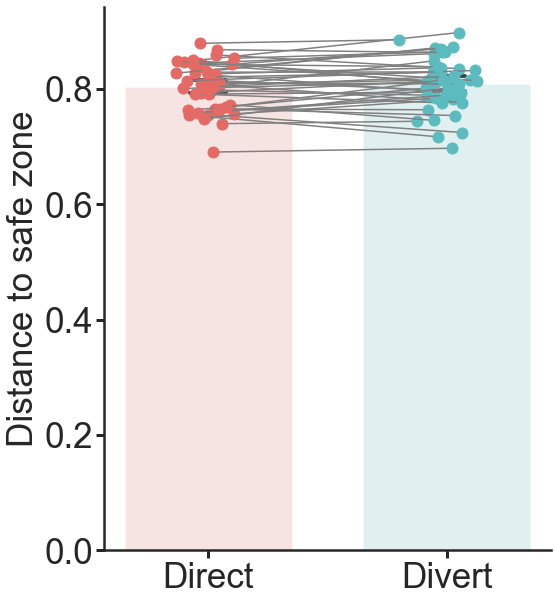

In [10]:
# 画所有被试的敌我距离
point_color = ['#E36A65', '#FF943C']
point_color = ['#E36A65','#5CBBBF']

all_data_df = {}
# all_data_df["Direct"] = list(-all_sub_behavior_result['high_mean_dv_stage3'])
# all_data_df["Divert"] = list(-all_sub_behavior_result['low_mean_dv_stage3'])

# 与安全区的位置
# all_data_df["Direct"] = list(1/all_sub_behavior_result['high_p_psafe_distance'])
# all_data_df["Divert"] = list(1/all_sub_behavior_result['low_p_psafe_distance'])
all_data_df["Direct"] = list(all_sub_behavior_result['high_p_psafe_distance'])
all_data_df["Divert"] = list(all_sub_behavior_result['low_p_psafe_distance'])


all_data_df = pd.DataFrame(all_data_df)

import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style("ticks"):

    plt.rcParams['figure.figsize'] = (8,10) # 设置figure_size尺寸

    # sns.boxplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#deefe8", "#f9e3d9"])
    # ['#E36A65','#FF943C'] 
    sns.barplot(data=all_data_df, palette=point_color, width=0.7,capsize=0.15, errwidth=4, alpha=0.2)
    # sns.stripplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#66c2a5", "#fc8d62"], size=4)
    # sns.stripplot(data=all_data_df, palette=["#E36A65", "#5CBBBF", "#f9e3d9"], size=10)    # violinplot plot
    
    # 在横轴上略微打乱一下点 （替代stripplot）
    jitter = 0.07
    df_x_jitter = pd.DataFrame(np.random.normal(loc=0, scale=jitter, size=all_data_df.values.shape), columns=all_data_df.columns)
    df_x_jitter += np.arange(len(all_data_df.columns))

    for i in range(len(all_data_df)):
        plt.plot([df_x_jitter["Direct"][i], df_x_jitter["Divert"][i]], [all_data_df["Direct"][i], all_data_df["Divert"][i]], color="grey")
        plt.plot(df_x_jitter["Direct"][i], all_data_df["Direct"][i], marker="o", color=point_color[0], markersize=11)
        plt.plot(df_x_jitter["Divert"][i], all_data_df["Divert"][i], marker="o", color=point_color[1], markersize=11)

    spines_width = 2.5
    ax=plt.gca()
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)
    sns.despine()
    ticksize = 35
    # plt.ylabel("Reaction time (s)", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape rate", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Average reward", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 3", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 4", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Alertness", size=ticksize, fontproperties='Arial')
    plt.ylabel("Distance to safe zone", size=ticksize, fontproperties='Arial')

    ticksize = 35
    # 坐标的粗细
    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    # plt.ylim([0.8, 1.2])

    # 刻度的粗细
    plt.tick_params(axis='x', width=3, size=8)
    plt.tick_params(axis='y', width=3, size=8)
    # plt.tight_layout()
# plt.savefig(r'D:\Desktop\项目\seeg\画图\fc_new\vmpfc_amy\psi_amy_vmpfc.jpg',dpi=500, overwrite=True)


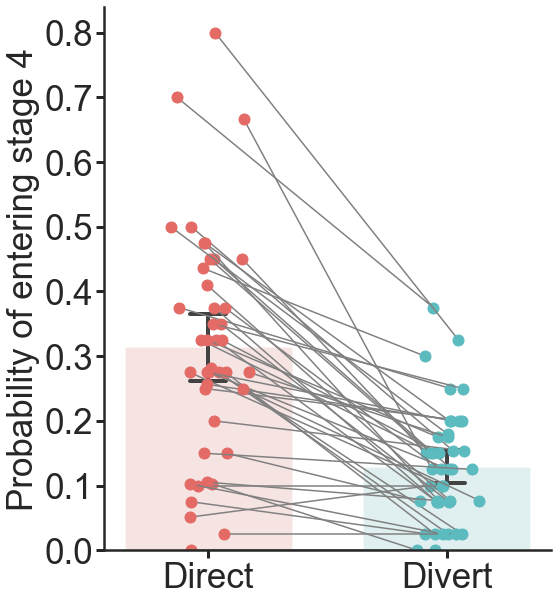

In [11]:
# high_p_pursuit_rate 进入stage4的概率
# 
point_color = ['#E36A65', '#FF943C']
point_color = ['#E36A65','#5CBBBF']

all_data_df = {}
# all_data_df["Direct"] = list(-all_sub_behavior_result['high_mean_dv_stage3'])
# all_data_df["Divert"] = list(-all_sub_behavior_result['low_mean_dv_stage3'])

# 正确率
all_data_df["Direct"] = list(all_sub_behavior_result['high_p_pursuit_rate'])
all_data_df["Divert"] = list(all_sub_behavior_result['low_p_pursuit_rate'])
# 平均奖励
# all_data_df["Direct"] = list(all_sub_behavior_result['high_p_avg_get_reward'])
# all_data_df["Divert"] = list(all_sub_behavior_result['low_p_avg_get_reward'])
# 反应时
# all_data_df["Direct"] = list(all_sub_behavior_result['high_mean_rt_stage3'])
# all_data_df["Divert"] = list(all_sub_behavior_result['low_mean_rt_stage3'])
# stage 3时的移动向量
# all_data_df["Direct"] = list(-all_sub_behavior_result['high_mean_dv_stage3'])
# all_data_df["Divert"] = list(-all_sub_behavior_result['low_mean_dv_stage3'])
# stage 4时的移动向量
# all_data_df["Direct"] = list(-all_sub_behavior_result['high_mean_dv_stage4'])
# all_data_df["Divert"] = list(-all_sub_behavior_result['low_mean_dv_stage4'])

all_data_df = pd.DataFrame(all_data_df)

import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style("ticks"):

    plt.rcParams['figure.figsize'] = (8,10) # 设置figure_size尺寸

    # sns.boxplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#deefe8", "#f9e3d9"])
    # ['#E36A65','#FF943C'] 
    sns.barplot(data=all_data_df, palette=point_color, width=0.7,capsize=0.15, errwidth=4, alpha=0.2)
    # sns.stripplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#66c2a5", "#fc8d62"], size=4)
    # sns.stripplot(data=all_data_df, palette=["#E36A65", "#5CBBBF", "#f9e3d9"], size=10)    # violinplot plot
    
    # 在横轴上略微打乱一下点 （替代stripplot）
    jitter = 0.07
    df_x_jitter = pd.DataFrame(np.random.normal(loc=0, scale=jitter, size=all_data_df.values.shape), columns=all_data_df.columns)
    df_x_jitter += np.arange(len(all_data_df.columns))

    for i in range(len(all_data_df)):
        plt.plot([df_x_jitter["Direct"][i], df_x_jitter["Divert"][i]], [all_data_df["Direct"][i], all_data_df["Divert"][i]], color="grey")
        plt.plot(df_x_jitter["Direct"][i], all_data_df["Direct"][i], marker="o", color=point_color[0], markersize=11)
        plt.plot(df_x_jitter["Divert"][i], all_data_df["Divert"][i], marker="o", color=point_color[1], markersize=11)

    spines_width = 2.5
    ax=plt.gca()
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)
    sns.despine()
    ticksize = 35
    # plt.ylabel("Reaction time (s)", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape rate", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Average reward", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 3", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 4", size=ticksize, fontproperties='Arial')
    plt.ylabel("Probability of entering stage 4", size=ticksize, fontproperties='Arial')

    ticksize = 35
    # 坐标的粗细
    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    # plt.ylim([0.8, 1.2])

    # 刻度的粗细
    plt.tick_params(axis='x', width=3, size=8)
    plt.tick_params(axis='y', width=3, size=8)
    # plt.tight_layout()
# plt.savefig(r'D:\Desktop\项目\seeg\画图\fc_new\vmpfc_amy\psi_amy_vmpfc.jpg',dpi=500, overwrite=True)


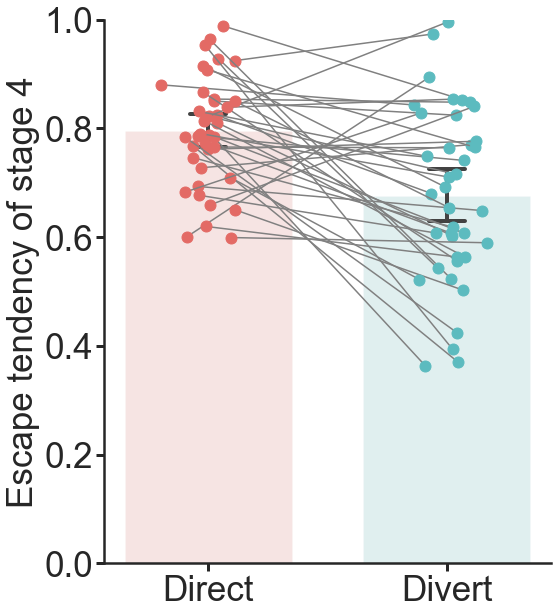

In [13]:
# 画所有被试的逃跑倾向性 stage 3/4
point_color = ['#E36A65', '#FF943C']
point_color = ['#E36A65','#5CBBBF']

all_data_df = {}

# stage 3时的移动向量
# all_data_df["Direct"] = list(-all_sub_behavior_result['high_mean_dv_stage3'])
# all_data_df["Divert"] = list(-all_sub_behavior_result['low_mean_dv_stage3'])
# stage 4时的移动向量
all_data_df["Direct"] = list(-all_sub_behavior_result_nostage4['high_mean_dv_stage4'])
all_data_df["Divert"] = list(-all_sub_behavior_result_nostage4['low_mean_dv_stage4'])

all_data_df = pd.DataFrame(all_data_df)

import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style("ticks"):

    plt.rcParams['figure.figsize'] = (8,10) # 设置figure_size尺寸

    # sns.boxplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#deefe8", "#f9e3d9"])
    # ['#E36A65','#FF943C'] 
    sns.barplot(data=all_data_df, palette=point_color, width=0.7,capsize=0.15, errwidth=4, alpha=0.2)
    # sns.stripplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#66c2a5", "#fc8d62"], size=4)
    # sns.stripplot(data=all_data_df, palette=["#E36A65", "#5CBBBF", "#f9e3d9"], size=10)    # violinplot plot
    
    # 在横轴上略微打乱一下点 （替代stripplot）
    jitter = 0.07
    df_x_jitter = pd.DataFrame(np.random.normal(loc=0, scale=jitter, size=all_data_df.values.shape), columns=all_data_df.columns)
    df_x_jitter += np.arange(len(all_data_df.columns))

    for i in range(len(all_data_df)):
        plt.plot([df_x_jitter["Direct"][i], df_x_jitter["Divert"][i]], [all_data_df["Direct"][i], all_data_df["Divert"][i]], color="grey")
        plt.plot(df_x_jitter["Direct"][i], all_data_df["Direct"][i], marker="o", color=point_color[0], markersize=11)
        plt.plot(df_x_jitter["Divert"][i], all_data_df["Divert"][i], marker="o", color=point_color[1], markersize=11)

    spines_width = 2.5
    ax=plt.gca()
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)
    sns.despine()
    ticksize = 35

    # plt.ylabel("Average reward", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 3", size=ticksize, fontproperties='Arial')
    plt.ylabel("Escape tendency of stage 4", size=ticksize, fontproperties='Arial')

    ticksize = 35
    # 坐标的粗细
    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    plt.ylim([0, 1])

    # 刻度的粗细
    plt.tick_params(axis='x', width=3, size=8)
    plt.tick_params(axis='y', width=3, size=8)
    # plt.tight_layout()
# plt.savefig(r'D:\Desktop\项目\seeg\画图\fc_new\vmpfc_amy\psi_amy_vmpfc.jpg',dpi=500, overwrite=True)


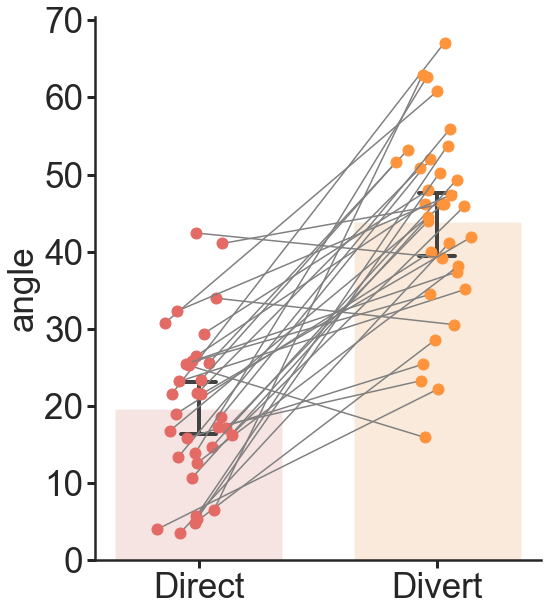

In [ ]:
# 画所有被试的逃跑方向和捕食者朝被试运动方向的夹角
point_color = ['#E36A65', '#FF943C']
point_color = ['#E36A65','#5CBBBF']

all_data_df = {}

# stage 3时的移动向量
# all_data_df["Direct"] = list(all_sub_behavior_result['high_pp_angle_stage3'])
# all_data_df["Divert"] = list(all_sub_behavior_result['low_pp_angle_stage3'])
# stage 4时的移动向量
all_sub_behavior_result_nostage4 = all_sub_behavior_result.dropna(subset=['low_pp_angle_stage4'])
all_data_df["Direct"] = list(all_sub_behavior_result_nostage4['high_pp_angle_stage4'])
all_data_df["Divert"] = list(all_sub_behavior_result_nostage4['low_pp_angle_stage4'])

all_data_df = pd.DataFrame(all_data_df)

import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style("ticks"):

    plt.rcParams['figure.figsize'] = (8,10) # 设置figure_size尺寸

    # sns.boxplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#deefe8", "#f9e3d9"])
    # ['#E36A65','#FF943C'] 
    sns.barplot(data=all_data_df, palette=point_color, width=0.7,capsize=0.15, errwidth=4, alpha=0.2)
    # sns.stripplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#66c2a5", "#fc8d62"], size=4)
    # sns.stripplot(data=all_data_df, palette=["#E36A65", "#5CBBBF", "#f9e3d9"], size=10)    # violinplot plot
    
    # 在横轴上略微打乱一下点 （替代stripplot）
    jitter = 0.07
    df_x_jitter = pd.DataFrame(np.random.normal(loc=0, scale=jitter, size=all_data_df.values.shape), columns=all_data_df.columns)
    df_x_jitter += np.arange(len(all_data_df.columns))

    for i in range(len(all_data_df)):
        plt.plot([df_x_jitter["Direct"][i], df_x_jitter["Divert"][i]], [all_data_df["Direct"][i], all_data_df["Divert"][i]], color="grey")
        plt.plot(df_x_jitter["Direct"][i], all_data_df["Direct"][i], marker="o", color=point_color[0], markersize=11)
        plt.plot(df_x_jitter["Divert"][i], all_data_df["Divert"][i], marker="o", color=point_color[1], markersize=11)

    spines_width = 2.5
    ax=plt.gca()
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)
    sns.despine()
    ticksize = 35

    # plt.ylabel("Average reward", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 3", size=ticksize, fontproperties='Arial')
    plt.ylabel("angle", size=ticksize, fontproperties='Arial')

    ticksize = 35
    # 坐标的粗细
    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    # plt.ylim([0, 1])

    # 刻度的粗细
    plt.tick_params(axis='x', width=3, size=8)
    plt.tick_params(axis='y', width=3, size=8)
    # plt.tight_layout()
# plt.savefig(r'D:\Desktop\项目\seeg\画图\fc_new\vmpfc_amy\psi_amy_vmpfc.jpg',dpi=500, overwrite=True)


# 计算p值和相关性


In [ ]:
# high
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

all_sub_behavior_result_clean['high_mean_dv_stage3'] = -all_sub_behavior_result_clean['high_mean_dv_stage3']

# 定义自变量和因变量
X = all_sub_behavior_result_clean[['high_mean_dv_stage3',  'high_mean_rt_stage34', 'high_p_psafe_distance','high_stationary_ratio_stage_3']]
# X = all_sub_behavior_result_clean[['high_alertness', 'high_mean_rt_stage34', 'high_mean_dv_stage3', 'high_stationary_ratio_stage_3']]

y = all_sub_behavior_result_clean['high_p_safe_rate']

# 标准化自变量
scaler = StandardScaler()
# y = scaler.fit_transform(y)
X_scaled = scaler.fit_transform(X)
# X_scaled = X
# 添加常数项
X_scaled = sm.add_constant(X_scaled)

# 设置参数
alpha = 1.0  # 正则化参数
n_permutations = 10000  # 置换次数
L1_wt = 0  # 0 ridge 1 lasso
# 存储置换检验的系数
permuted_coefficients = np.zeros((n_permutations, X_scaled.shape[1]))

# 原始模型
original_model = sm.OLS(y, X_scaled).fit_regularized(method='elastic_net', alpha=alpha, L1_wt=L1_wt)
original_coefficients = original_model.params

# 置换检验
for i in range(n_permutations):
    # 打乱因变量
    y_permuted = np.random.permutation(y)
    
    # 创建岭回归模型
    permuted_model = sm.OLS(y_permuted, X_scaled).fit_regularized(method='elastic_net', alpha=alpha, L1_wt=L1_wt)
    
    # 存储系数
    permuted_coefficients[i, :] = permuted_model.params

# 计算每个系数的位置
p_values = []
for i, feature in enumerate(['const'] + X.columns.tolist()):
    # 计算原始系数在置换分布中的位置
    greater_count = np.sum(np.abs(permuted_coefficients[:, i]) >= np.abs(original_coefficients[i]))
    # greater_count = np.sum(permuted_coefficients[:, i] >= original_coefficients[i])

    p_value = greater_count / n_permutations
    p_values.append(p_value)
    
    print(f"{feature}: Original Coefficient = {original_coefficients[i]:.4f}, p-value = {p_value:.4f}")

# 打印结果
print("\n置换检验结果:")
for i, feature in enumerate(['const'] + X.columns.tolist()):
    print(f"{feature}: p-value = {p_values[i]:.4f}")

const: Original Coefficient = 0.3627, p-value = 0.6690
high_mean_dv_stage3: Original Coefficient = 0.0574, p-value = 0.0000
high_mean_rt_stage34: Original Coefficient = -0.0109, p-value = 0.2981
high_p_psafe_distance: Original Coefficient = -0.0331, p-value = 0.0007
high_stationary_ratio_stage_3: Original Coefficient = 0.0019, p-value = 0.8526

置换检验结果:
const: p-value = 0.6690
high_mean_dv_stage3: p-value = 0.0000
high_mean_rt_stage34: p-value = 0.2981
high_p_psafe_distance: p-value = 0.0007
high_stationary_ratio_stage_3: p-value = 0.8526


<ipython-input-9-b3a60ed0f0b2>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(permuted_coefficients[:, i], bins=25, color='#E36A65',hist_kws={'rwidth': 0.7})   # kdeplot
d:\ProgramData\Anaconda3\envs\data_process\lib\site-packages\numpy\lib\histograms.py:905: RuntimeWarning: divide by zero encountered in true_divide
  return n/db/n.sum(), bin_edges
d:\ProgramData\Anaconda3\envs\data_process\lib\site-packages\numpy\lib\histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges


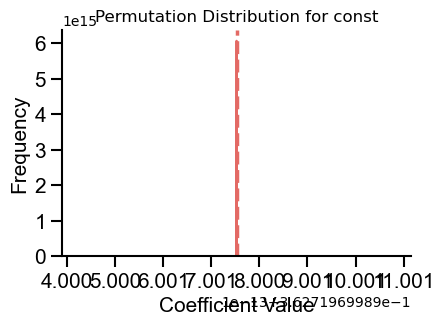

<ipython-input-9-b3a60ed0f0b2>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(permuted_coefficients[:, i], bins=25, color='#E36A65',hist_kws={'rwidth': 0.7})   # kdeplot


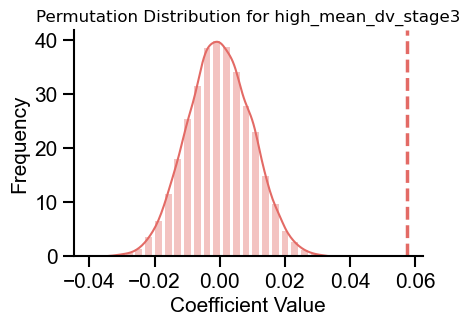

<ipython-input-9-b3a60ed0f0b2>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(permuted_coefficients[:, i], bins=25, color='#E36A65',hist_kws={'rwidth': 0.7})   # kdeplot


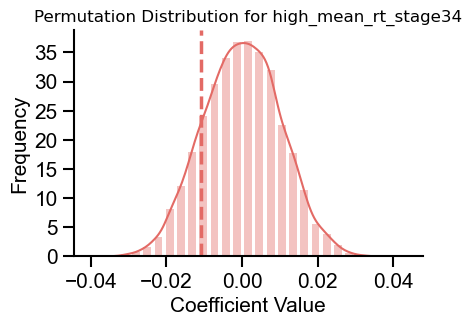

<ipython-input-9-b3a60ed0f0b2>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(permuted_coefficients[:, i], bins=25, color='#E36A65',hist_kws={'rwidth': 0.7})   # kdeplot


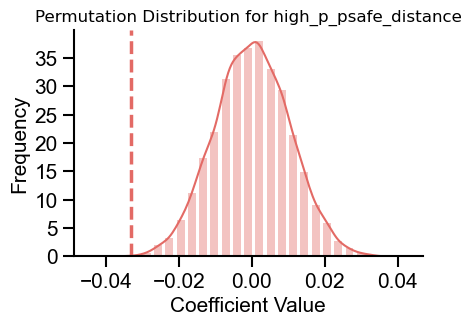

<ipython-input-9-b3a60ed0f0b2>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(permuted_coefficients[:, i], bins=25, color='#E36A65',hist_kws={'rwidth': 0.7})   # kdeplot


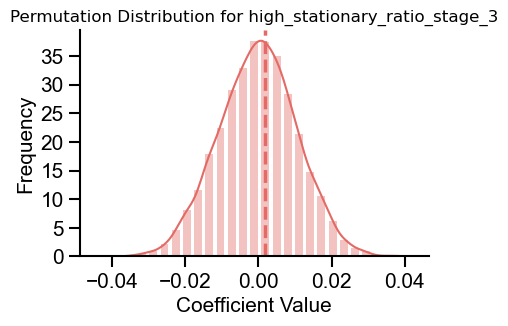

In [9]:
# 可视化结果
import seaborn as sns
import matplotlib.pyplot as plt
features = ['const'] + X.columns.tolist()
for i, feature in enumerate(features):
    bins_interval= 1/100
    bins =np.arange(min(permuted_coefficients[:, i]) - bins_interval/2, max(permuted_coefficients[:, i])+bins_interval/2, bins_interval)
    plt.figure(figsize=(4.5,3),dpi=100)
    sns.distplot(permuted_coefficients[:, i], bins=25, color='#E36A65',hist_kws={'rwidth': 0.7})   # kdeplot

    # plt.hist(permuted_coefficients[:, i], bins=50, color='#FCC3AA', edgecolor='#FCC3AA')
    plt.axvline(original_coefficients[i], color='#E36A65', linestyle='dashed', linewidth=2.5)
    plt.title(f'Permutation Distribution for {feature}')
    ticksize = 15
    plt.xlabel('Coefficient Value',size=ticksize, fontproperties='Arial')
    plt.ylabel('Frequency',size=ticksize, fontproperties='Arial')
    
    
    # 坐标的粗细

    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    spines_width = 1.5
    ax=plt.gca()
    ax.spines['top'].set_linewidth(0)
    ax.spines['right'].set_linewidth(0)
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)

    # 刻度的粗细
    plt.tick_params(axis='x', width=1.5, size=8)
    plt.tick_params(axis='y', width=1.5, size=8)
    plt.show()

In [10]:
# low
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# 定义自变量和因变量

all_sub_behavior_result_clean['low_alertness'] = 1/all_sub_behavior_result_clean['low_p_psafe_distance']
all_sub_behavior_result_clean['low_mean_dv_stage3'] = -all_sub_behavior_result_clean['low_mean_dv_stage3']

# X = all_sub_behavior_result_clean[['low_alertness', 'low_mean_dv_stage3', 'low_mean_rt_stage34', 'low_p_avg_get_reward', 'low_stationary_ratio_stage_3']]
X = all_sub_behavior_result_clean[['low_mean_dv_stage3', 'low_mean_rt_stage34', 'low_p_psafe_distance', 'low_stationary_ratio_stage_3']]


y = all_sub_behavior_result_clean['low_p_safe_rate']

# 标准化自变量
scaler = StandardScaler()
# y = scaler.fit_transform(y)
X_scaled = scaler.fit_transform(X)
# X_scaled = X
# 添加常数项
X_scaled = sm.add_constant(X_scaled)

# 设置参数
alpha = 1  # 正则化参数
n_permutations = 10000  # 置换次数
L1_wt = 0.  # 0 ridge 1 lasso
# 存储置换检验的系数
permuted_coefficients = np.zeros((n_permutations, X_scaled.shape[1]))

# 原始模型
original_model = sm.OLS(y, X_scaled).fit_regularized(method='elastic_net', alpha=alpha, L1_wt=L1_wt)
original_coefficients = original_model.params

# 置换检验
for i in range(n_permutations):
    # 打乱因变量
    y_permuted = np.random.permutation(y)
    
    # 创建岭回归模型
    permuted_model = sm.OLS(y_permuted, X_scaled).fit_regularized(method='elastic_net', alpha=alpha, L1_wt=L1_wt)
    
    # 存储系数
    permuted_coefficients[i, :] = permuted_model.params

# 计算每个系数的位置
p_values = []
for i, feature in enumerate(['const'] + X.columns.tolist()):
    # 计算原始系数在置换分布中的位置
    greater_count = np.sum(np.abs(permuted_coefficients[:, i]) >= np.abs(original_coefficients[i]))
    # greater_count = np.sum(permuted_coefficients[:, i] >= original_coefficients[i])

    p_value = greater_count / n_permutations
    p_values.append(p_value)
    
    print(f"{feature}: Original Coefficient = {original_coefficients[i]:.4f}, p-value = {p_value:.4f}")

# 打印结果
print("\n置换检验结果:")
for i, feature in enumerate(['const'] + X.columns.tolist()):
    print(f"{feature}: p-value = {p_values[i]:.4f}")

const: Original Coefficient = 0.4355, p-value = 0.7645
low_mean_dv_stage3: Original Coefficient = -0.0001, p-value = 0.9829
low_mean_rt_stage34: Original Coefficient = -0.0198, p-value = 0.0020
low_p_psafe_distance: Original Coefficient = -0.0173, p-value = 0.0058
low_stationary_ratio_stage_3: Original Coefficient = 0.0113, p-value = 0.0798

置换检验结果:
const: p-value = 0.7645
low_mean_dv_stage3: p-value = 0.9829
low_mean_rt_stage34: p-value = 0.0020
low_p_psafe_distance: p-value = 0.0058
low_stationary_ratio_stage_3: p-value = 0.0798


<ipython-input-11-481a9b09b2f8>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(permuted_coefficients[:, i], bins=25, color='#5CBBBF',hist_kws={'rwidth': 0.7})   # kdeplot
d:\ProgramData\Anaconda3\envs\data_process\lib\site-packages\numpy\lib\histograms.py:905: RuntimeWarning: divide by zero encountered in true_divide
  return n/db/n.sum(), bin_edges
d:\ProgramData\Anaconda3\envs\data_process\lib\site-packages\numpy\lib\histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges


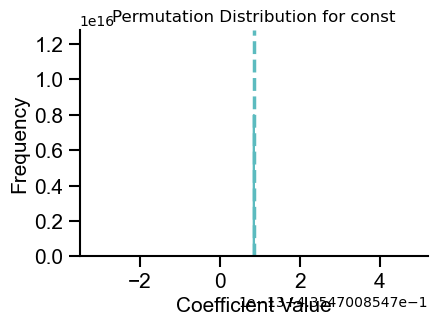

<ipython-input-11-481a9b09b2f8>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(permuted_coefficients[:, i], bins=25, color='#5CBBBF',hist_kws={'rwidth': 0.7})   # kdeplot


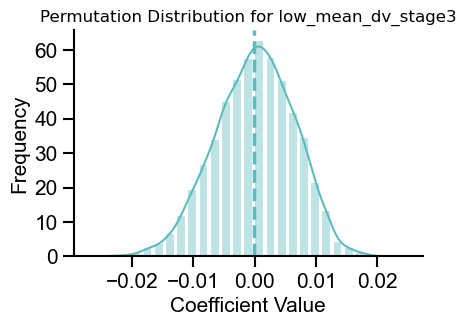

<ipython-input-11-481a9b09b2f8>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(permuted_coefficients[:, i], bins=25, color='#5CBBBF',hist_kws={'rwidth': 0.7})   # kdeplot


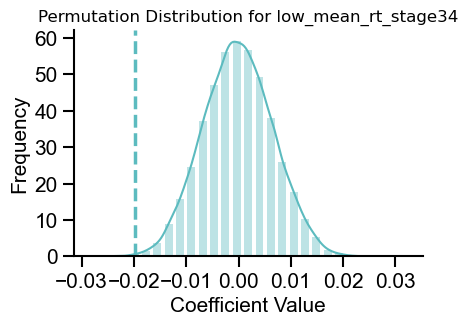

<ipython-input-11-481a9b09b2f8>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(permuted_coefficients[:, i], bins=25, color='#5CBBBF',hist_kws={'rwidth': 0.7})   # kdeplot


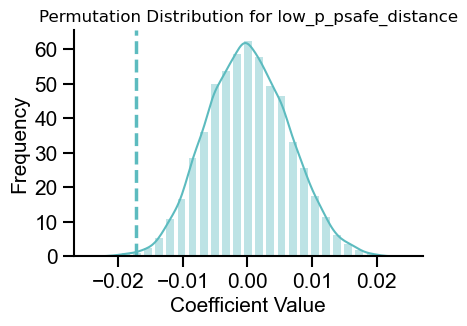

<ipython-input-11-481a9b09b2f8>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(permuted_coefficients[:, i], bins=25, color='#5CBBBF',hist_kws={'rwidth': 0.7})   # kdeplot


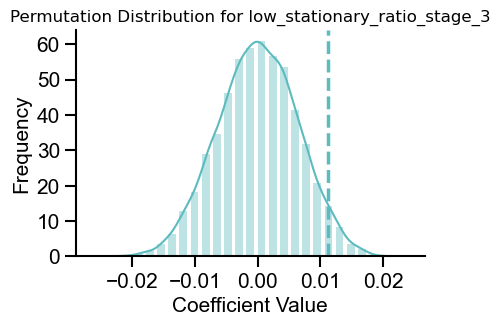

In [11]:
# 可视化结果
import seaborn as sns
import matplotlib.pyplot as plt
features = ['const'] + X.columns.tolist()
for i, feature in enumerate(features):
    bins_interval= 1/100
    bins =np.arange(min(permuted_coefficients[:, i]) - bins_interval/2, max(permuted_coefficients[:, i])+bins_interval/2, bins_interval)
    plt.figure(figsize=(4.5,3),dpi=100)
    sns.distplot(permuted_coefficients[:, i], bins=25, color='#5CBBBF',hist_kws={'rwidth': 0.7})   # kdeplot
    ticksize = 15
    # plt.hist(permuted_coefficients[:, i], bins=50, color='#FCC3AA', edgecolor='#FCC3AA')
    plt.axvline(original_coefficients[i], color='#5CBBBF', linestyle='dashed', linewidth=2.5)
    plt.title(f'Permutation Distribution for {feature}')
    plt.xlabel('Coefficient Value',size=ticksize, fontproperties='Arial')
    plt.ylabel('Frequency',size=ticksize, fontproperties='Arial')
    
    ticksize = 15
    # 坐标的粗细

    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    spines_width = 1.5
    ax=plt.gca()
    ax.spines['top'].set_linewidth(0)
    ax.spines['right'].set_linewidth(0)
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)

    # 刻度的粗细
    plt.tick_params(axis='x', width=1.5, size=8)
    plt.tick_params(axis='y', width=1.5, size=8)
    plt.show()

In [12]:
# low
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
all_sub_behavior_result_clean['low_alertness'] = 1/all_sub_behavior_result_clean['low_p_psafe_distance']
all_sub_behavior_result_clean['low_mean_dv_stage3'] = -all_sub_behavior_result_clean['low_mean_dv_stage3']

# 定义自变量和因变量
X = all_sub_behavior_result_clean[['low_mean_dv_stage3', 'low_mean_rt_stage34', 'low_p_psafe_distance', 'low_stationary_ratio_stage_3']]
y = all_sub_behavior_result_clean['low_stage5_rate']

# 标准化自变量
scaler = StandardScaler()
# y = scaler.fit_transform(y)
X_scaled = scaler.fit_transform(X)
# X_scaled = X
# 添加常数项
X_scaled = sm.add_constant(X_scaled)

# 设置参数
alpha = 1.0  # 正则化参数
n_permutations = 10000  # 置换次数
L1_wt = 0  # 0 ridge 1 lasso
# 存储置换检验的系数
permuted_coefficients = np.zeros((n_permutations, X_scaled.shape[1]))

# 原始模型
original_model = sm.OLS(y, X_scaled).fit_regularized(method='elastic_net', alpha=alpha, L1_wt=L1_wt)
original_coefficients = original_model.params

# 置换检验
for i in range(n_permutations):
    # 打乱因变量
    y_permuted = np.random.permutation(y)
    
    # 创建岭回归模型
    permuted_model = sm.OLS(y_permuted, X_scaled).fit_regularized(method='elastic_net', alpha=alpha, L1_wt=L1_wt)
    
    # 存储系数
    permuted_coefficients[i, :] = permuted_model.params

# 计算每个系数的位置
p_values = []
for i, feature in enumerate(['const'] + X.columns.tolist()):
    # 计算原始系数在置换分布中的位置
    greater_count = np.sum(np.abs(permuted_coefficients[:, i]) >= np.abs(original_coefficients[i]))
    # greater_count = np.sum(permuted_coefficients[:, i] >= original_coefficients[i])

    p_value = greater_count / n_permutations
    p_values.append(p_value)
    
    print(f"{feature}: Original Coefficient = {original_coefficients[i]:.4f}, p-value = {p_value:.4f}")

# 打印结果
print("\n置换检验结果:")
for i, feature in enumerate(['const'] + X.columns.tolist()):
    print(f"{feature}: p-value = {p_values[i]:.4f}")

const: Original Coefficient = 0.3967, p-value = 0.4920
low_mean_dv_stage3: Original Coefficient = 0.0131, p-value = 0.1873
low_mean_rt_stage34: Original Coefficient = -0.0175, p-value = 0.0891
low_p_psafe_distance: Original Coefficient = -0.0315, p-value = 0.0006
low_stationary_ratio_stage_3: Original Coefficient = 0.0306, p-value = 0.0010

置换检验结果:
const: p-value = 0.4920
low_mean_dv_stage3: p-value = 0.1873
low_mean_rt_stage34: p-value = 0.0891
low_p_psafe_distance: p-value = 0.0006
low_stationary_ratio_stage_3: p-value = 0.0010


<ipython-input-13-1bafc733d1da>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(permuted_coefficients[:, i], bins=25, color='#5CBBBF',hist_kws={'rwidth': 0.7})   # kdeplot
d:\ProgramData\Anaconda3\envs\data_process\lib\site-packages\numpy\lib\histograms.py:905: RuntimeWarning: divide by zero encountered in true_divide
  return n/db/n.sum(), bin_edges
d:\ProgramData\Anaconda3\envs\data_process\lib\site-packages\numpy\lib\histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges


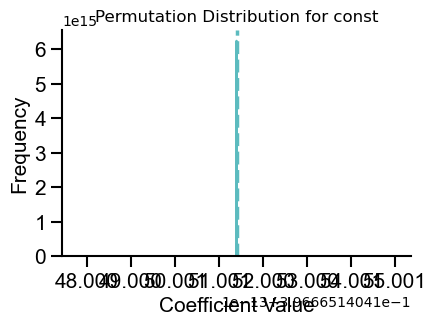

<ipython-input-13-1bafc733d1da>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(permuted_coefficients[:, i], bins=25, color='#5CBBBF',hist_kws={'rwidth': 0.7})   # kdeplot


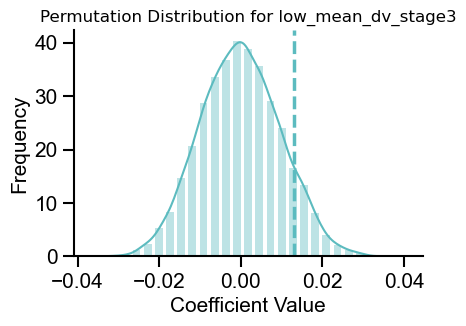

<ipython-input-13-1bafc733d1da>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(permuted_coefficients[:, i], bins=25, color='#5CBBBF',hist_kws={'rwidth': 0.7})   # kdeplot


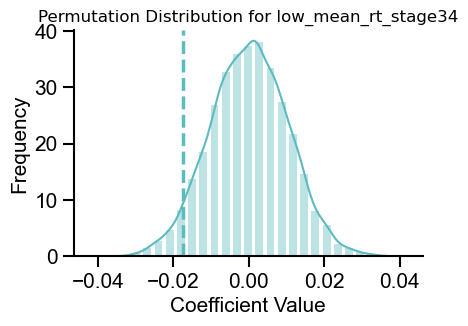

<ipython-input-13-1bafc733d1da>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(permuted_coefficients[:, i], bins=25, color='#5CBBBF',hist_kws={'rwidth': 0.7})   # kdeplot


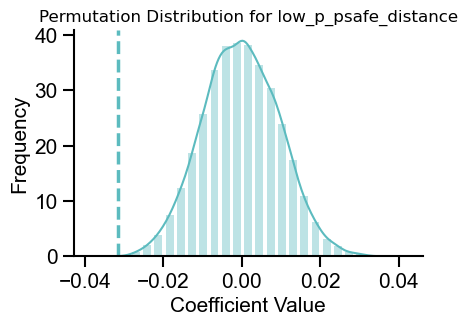

<ipython-input-13-1bafc733d1da>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(permuted_coefficients[:, i], bins=25, color='#5CBBBF',hist_kws={'rwidth': 0.7})   # kdeplot


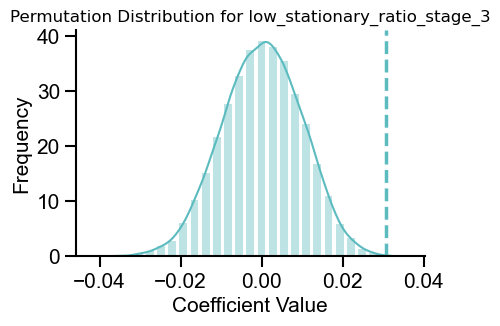

In [13]:
# 可视化结果
import seaborn as sns
import matplotlib.pyplot as plt
features = ['const'] + X.columns.tolist()
for i, feature in enumerate(features):
    bins_interval= 1/100
    bins =np.arange(min(permuted_coefficients[:, i]) - bins_interval/2, max(permuted_coefficients[:, i])+bins_interval/2, bins_interval)
    plt.figure(figsize=(4.5,3),dpi=100)
    sns.distplot(permuted_coefficients[:, i], bins=25, color='#5CBBBF',hist_kws={'rwidth': 0.7})   # kdeplot

    # plt.hist(permuted_coefficients[:, i], bins=50, color='#FCC3AA', edgecolor='#FCC3AA')
    plt.axvline(original_coefficients[i], color='#5CBBBF', linestyle='dashed', linewidth=2.5)
    plt.title(f'Permutation Distribution for {feature}')
    plt.xlabel('Coefficient Value',size=ticksize, fontproperties='Arial')
    plt.ylabel('Frequency',size=ticksize, fontproperties='Arial')
    
    ticksize = 15
    # 坐标的粗细

    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    spines_width = 1.5
    ax=plt.gca()
    ax.spines['top'].set_linewidth(0)
    ax.spines['right'].set_linewidth(0)
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)

    # 刻度的粗细
    plt.tick_params(axis='x', width=1.5, size=8)
    plt.tick_params(axis='y', width=1.5, size=8)
    plt.show()

In [21]:
from scipy import stats



# 进行单样本 t 检验
t_statistic, p_value = stats.ttest_1samp(coefficients[ :, 4], 0)
print(t_statistic, p_value)

-24.5195110672556 2.576034091489667e-104


In [33]:
import numpy as np
from scipy.stats import pearsonr
 

# 计算相关系数
correlation, p_value = pearsonr(all_sub_behavior_result['high_p_safe_rate'], all_sub_behavior_result['high_mean_rt_stage3'])
 
print(f"相关系数: {correlation}, p值: {p_value}")

相关系数: 0.016318424457251707, p值: 0.9247427453322111


# 分布密度


In [50]:
array==[]

True

In [41]:
#
from ast import literal_eval
import numpy as np
import matplotlib.pyplot as plt

behavior_path = "E:/workspace/study2_escape_task_eeg/behavior/" # 分析哪个roi就输入哪个文件夹的数据
# subjects = [2, 4, 5, 6, 8, 9, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22]
subjects = [4, 5, 6, 8, 9, 11, 12, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,39,40,41,42,43,45] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少
subjects = [4, 5, 6, 8, 9, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,39,40,41,42,43,45] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少

std_x_high, std_x_low=[], []
std_y_high, std_y_low=[], []

all_sub_behavior_result = pd.DataFrame([])
for iter_subject in subjects:

    behavior_folder = behavior_path + str(iter_subject) + '/'
    trial_dict = pd.read_excel(behavior_folder + '/subject_v3.xlsx')

    trial_dict['traj_stage_3'] = trial_dict['traj_stage_3'].apply(literal_eval) 
    high_traj_stage_3 = trial_dict['traj_stage_3'][trial_dict['event_num'].isin([21,22,23])]
    low_traj_stage_3 = trial_dict['traj_stage_3'][trial_dict['event_num'].isin([31,32])]

    ## high
    # 初始化一个空数组
    high_traj_stage_3 = [item for item in np.array(high_traj_stage_3) if item != []]
    merged_data_high_traj_stage_3 = np.array(np.array(high_traj_stage_3)[0])
    # 循环合并
    for array in np.array(high_traj_stage_3)[1:]:
        merged_data_high_traj_stage_3 = np.vstack((merged_data_high_traj_stage_3, np.array(array)))

    ## low
    # 初始化一个空数组
    low_traj_stage_3 = [item for item in np.array(low_traj_stage_3) if item != []]
    merged_data_low_traj_stage_3 = np.array(np.array(low_traj_stage_3)[0])
    # 循环合并
    for array in np.array(low_traj_stage_3)[1:]:
        
        merged_data_low_traj_stage_3 = np.vstack((merged_data_low_traj_stage_3, np.array(array)))

    if iter_subject == 4:
        all_sub_merged_high = merged_data_high_traj_stage_3
        all_sub_merged_low = merged_data_low_traj_stage_3
    else:
        all_sub_merged_high = np.vstack((all_sub_merged_high, merged_data_high_traj_stage_3))
        all_sub_merged_low = np.vstack((all_sub_merged_low, merged_data_low_traj_stage_3))


    # 标准差
    std_x_high.append(np.std(all_sub_merged_high[:, 0]))
    std_x_low.append(np.std(all_sub_merged_low[:, 0]))
    std_y_high.append(np.std(all_sub_merged_high[:, 1]))
    std_y_low.append(np.std(all_sub_merged_low[:, 1]))



<ipython-input-41-3a348b0f61e7>:27: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  merged_data_high_traj_stage_3 = np.array(np.array(high_traj_stage_3)[0])
<ipython-input-41-3a348b0f61e7>:29: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  for array in np.array(high_traj_stage_3)[1:]:
<ipython-input-41-3a348b0f61e7>:35: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object

In [139]:
# 345
from ast import literal_eval
import numpy as np
import matplotlib.pyplot as plt

behavior_path = "E:/workspace/study2_escape_task_eeg/behavior/" # 分析哪个roi就输入哪个文件夹的数据
# subjects = [2, 4, 5, 6, 8, 9, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22]
subjects = [4, 5, 6, 8, 9, 11, 12, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,39,40,41,42,43,45] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少

std_x_high, std_x_low=[], []
std_y_high, std_y_low=[], []

all_sub_behavior_result = pd.DataFrame([])
for iter_subject in subjects:

    behavior_folder = behavior_path + str(iter_subject) + '/'
    trial_dict = pd.read_excel(behavior_folder + '/subject_v3.xlsx')

    trial_dict['traj_stage_4'] = trial_dict['traj_stage_4'].apply(literal_eval) 
    high_traj_stage_3 = trial_dict['traj_stage_4'][trial_dict['event_num'].isin([21,22,23])]
    low_traj_stage_3 = trial_dict['traj_stage_4'][trial_dict['event_num'].isin([31,32])]

    ## high
    # 初始化一个空数组
    high_traj_stage_3 = [item for item in np.array(high_traj_stage_3) if item != []]
    merged_data_high_traj_stage_3 = np.array(np.array(high_traj_stage_3)[0])
    # 循环合并
    for array in np.array(high_traj_stage_3)[1:]:
        merged_data_high_traj_stage_3 = np.vstack((merged_data_high_traj_stage_3, np.array(array)))

    ## low
    # 初始化一个空数组
    low_traj_stage_3 = [item for item in np.array(low_traj_stage_3) if item != []]
    merged_data_low_traj_stage_3 = np.array(np.array(low_traj_stage_3)[0])
    # 循环合并
    for array in np.array(low_traj_stage_3)[1:]:
        
        merged_data_low_traj_stage_3 = np.vstack((merged_data_low_traj_stage_3, np.array(array)))

    if iter_subject == 4:
        all_sub_merged_high = merged_data_high_traj_stage_3
        all_sub_merged_low = merged_data_low_traj_stage_3
    else:
        all_sub_merged_high = np.vstack((all_sub_merged_high, merged_data_high_traj_stage_3))
        all_sub_merged_low = np.vstack((all_sub_merged_low, merged_data_low_traj_stage_3))


    # 标准差
    std_x_high.append(np.std(all_sub_merged_high[:, 0]))
    std_x_low.append(np.std(all_sub_merged_low[:, 0]))
    std_y_high.append(np.std(all_sub_merged_high[:, 1]))
    std_y_low.append(np.std(all_sub_merged_low[:, 1]))



IndexError: index 0 is out of bounds for axis 0 with size 0

In [18]:
trial_dict['traj_stage_345'][0]

'[[-0.08666272000009485, 0.09992631999994056], [-0.08666272000009485, 0.09325907999991624], [-0.08666272000009485, 0.08655399999988742], [-0.08666272000009485, 0.07990083999993669], [-0.08666272000009485, 0.07326904000001389], [-0.08666272000009485, 0.06660639999990974], [-0.08666272000009485, 0.0599190799999634], [-0.08666272000009485, 0.05325131999998131], [-0.08666272000009485, 0.04656971999993413], [-0.08666272000009485, 0.03992192000005172], [-0.08666272000009485, 0.033257479999883904], [-0.08666272000009485, 0.0265917200000332], [-0.08666272000009485, 0.0199023600000147], [-0.08666272000009485, 0.013265440000032063], [-0.08666272000009485, 0.006546879999950865], [-0.08666272000009485, -0.00012220000007790582], [-0.08666272000009485, -0.006733720000010986], [-0.08666272000009485, -0.013382439999986569], [-0.08666272000009485, -0.020065760000033957], [-0.08666272000009485, -0.026741039999978865], [-0.08666272000009485, -0.033439040000121066], [-0.08666272000009485, -0.0401199600000

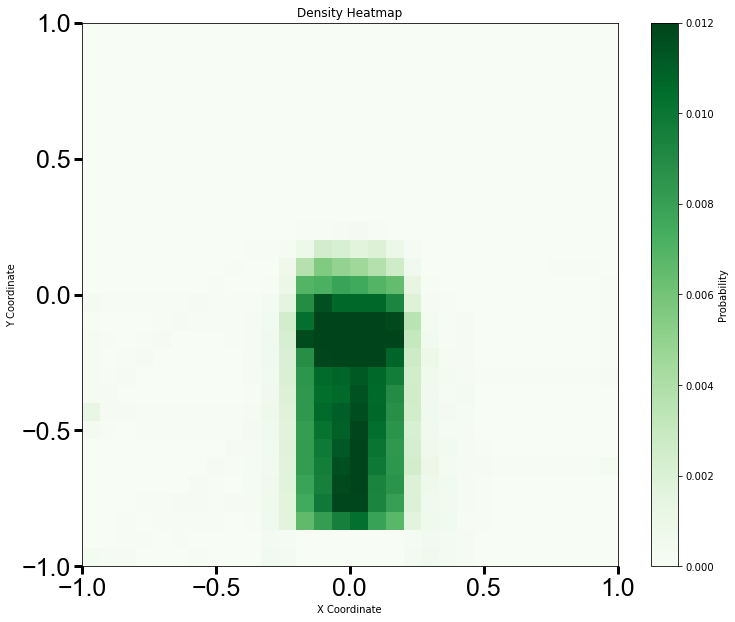

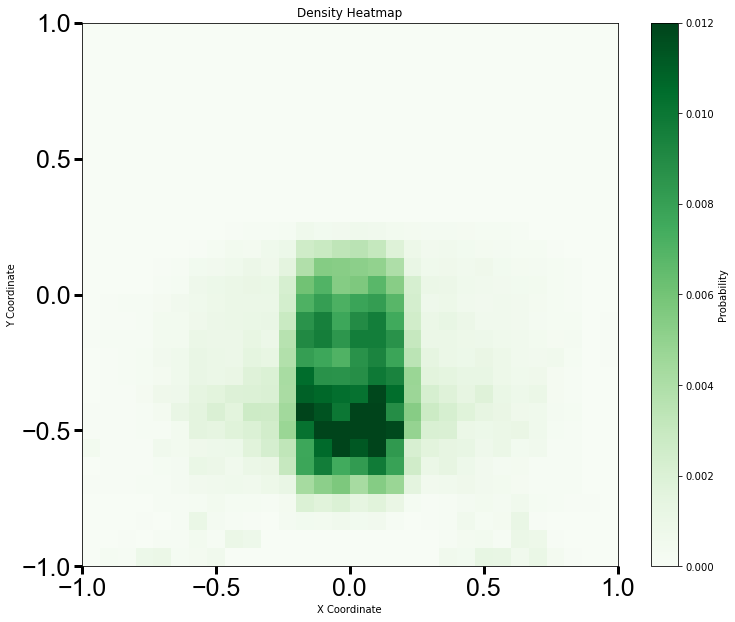

In [58]:
bins=30
# 绘制热力图
plt.figure(figsize=(12, 10))

counts, xedges, yedges, _ = plt.hist2d(all_sub_merged_high[:, 0], all_sub_merged_high[:, 1], bins=bins, range=[[-1, 1], [-1, 1]], cmap='Reds')
# 将计数标准化为概率
probabilities = counts / np.sum(counts)

# 清除之前的图
plt.clf()
plt.imshow(probabilities.T, extent=[-1, 1,-1, 1], origin='lower', cmap='Greens', aspect='auto', vmin=0, vmax=0.012) # RdBu_r
plt.colorbar(label='Probability')
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=25)
ticksize = 25
# 坐标的粗细
plt.xticks(np.arange(-1, 1 + 0.5, 0.5))
plt.yticks(np.arange(-1, 1 + 0.5, 0.5))
plt.yticks(size=ticksize, fontproperties='Arial')
plt.xticks(size=ticksize, fontproperties='Arial')

# 刻度的粗细
plt.tick_params(axis='x', width=3, size=8)
plt.tick_params(axis='y', width=3, size=8)

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Density Heatmap')
plt.xlim([-1, 1])
plt.ylim([-1, 1])
plt.show()

# print(merged_data.shape)
# 绘制热力图
plt.figure(figsize=(12, 10))

counts, xedges, yedges, _ = plt.hist2d(all_sub_merged_low[:, 0], all_sub_merged_low[:, 1], bins=bins, range=[[-1, 1], [-1, 1]], cmap='Reds')
# 将计数标准化为概率
probabilities = counts / np.sum(counts)

# plt.imshow(probabilities, cmap='hot', interpolation='nearest')

plt.clf()
plt.imshow(probabilities.T, extent=[-1, 1,-1, 1], origin='lower', cmap='Greens', aspect='auto', vmin=0, vmax=0.012)
plt.colorbar(label='Probability')
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=25)
# plt.imshow(counts.T, extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]], origin='lower', cmap='hot', aspect='auto') RdBu_r
# plt.colorbar(label='Density')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Density Heatmap')

ticksize = 25
# 坐标的粗细
plt.xticks(np.arange(-1, 1 + 0.5, 0.5))
plt.yticks(np.arange(-1, 1 + 0.5, 0.5))

plt.yticks(size=ticksize, fontproperties='Arial')
plt.xticks(size=ticksize, fontproperties='Arial')

# 刻度的粗细
plt.tick_params(axis='x', width=3, size=8)
plt.tick_params(axis='y', width=3, size=8)
plt.xlim([-1, 1])
plt.ylim([-1, 1])
plt.show()
# print(merged_data.shape)

统计检验
0.1572121300883056 0.25094567556933334 (-20.777375711864646, 1.2338464551977842e-21, False)


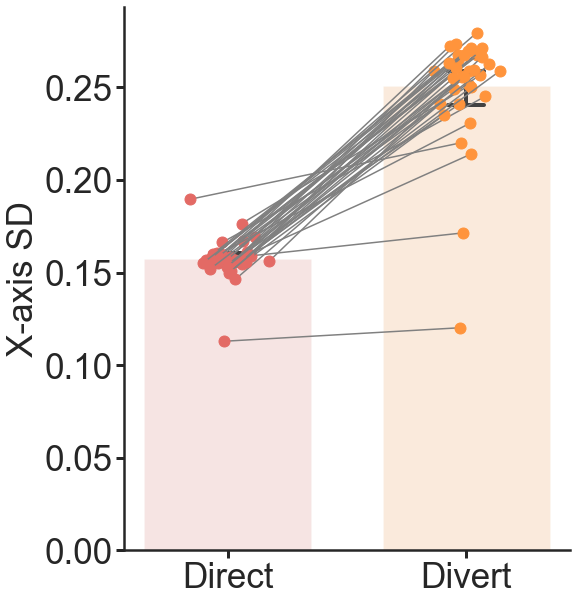

In [59]:
# 画所有被试的敌我距离
import numpy as np
from supply import *

import sys
sys.path.insert(0, 'E:/workspace/my_py_toolbox/') 
from hm_tools import *
point_color = ['#E36A65', '#FF943C']
all_data_df = {}

# 正确率
all_data_df["Direct"] = std_x_high
all_data_df["Divert"] = std_x_low
# 平均奖励
print('统计检验')
# all_sub_behavior_result['low_p_avg_get_reward'] 
# all_sub_behavior_result['high_p_avg_get_reward'] 
print(np.mean(all_data_df["Direct"]), np.mean(all_data_df["Divert"]), hm_t_test_rel(all_data_df["Direct"],all_data_df["Divert"]))

all_data_df = pd.DataFrame(all_data_df)

import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style("ticks"):

    plt.rcParams['figure.figsize'] = (8,10) # 设置figure_size尺寸


    sns.barplot(data=all_data_df, palette=point_color, width=0.7,capsize=0.15, errwidth=4, alpha=0.2)

    # 在横轴上略微打乱一下点 （替代stripplot）
    jitter = 0.07
    df_x_jitter = pd.DataFrame(np.random.normal(loc=0, scale=jitter, size=all_data_df.values.shape), columns=all_data_df.columns)
    df_x_jitter += np.arange(len(all_data_df.columns))

    for i in range(len(all_data_df)):
        plt.plot([df_x_jitter["Direct"][i], df_x_jitter["Divert"][i]], [all_data_df["Direct"][i], all_data_df["Divert"][i]], color="grey")
        plt.plot(df_x_jitter["Direct"][i], all_data_df["Direct"][i], marker="o", color=point_color[0], markersize=11)
        plt.plot(df_x_jitter["Divert"][i], all_data_df["Divert"][i], marker="o", color=point_color[1], markersize=11)

    spines_width = 2.5
    ax=plt.gca()
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)
    sns.despine()
    ticksize = 35

    plt.ylabel("X-axis SD", size=ticksize, fontproperties='Arial')

    ticksize = 35
    # 坐标的粗细
    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    # plt.ylim([0.8, 1.2])

    # 刻度的粗细
    plt.tick_params(axis='x', width=3, size=8)
    plt.tick_params(axis='y', width=3, size=8)
    # plt.tight_layout()
# plt.savefig(r'D:\Desktop\项目\seeg\画图\fc_new\vmpfc_amy\psi_amy_vmpfc.jpg',dpi=500, overwrite=True)


0.27645099779515303 0.2501938311713959 (13.103840946013957, 2.8769055254277437e-15, False)


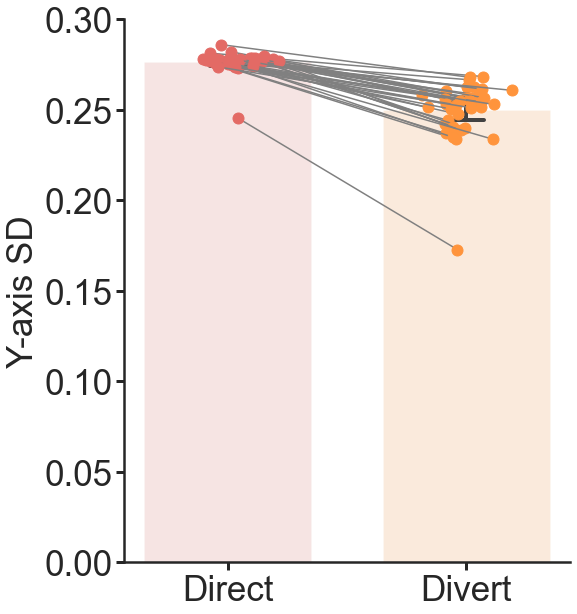

In [60]:
# 画所有被试的敌我距离
point_color = ['#E36A65', '#FF943C']
all_data_df = {}

# 正确率
all_data_df["Direct"] = std_y_high
all_data_df["Divert"] = std_y_low
# 平均奖励
print(np.mean(all_data_df["Direct"]), np.mean(all_data_df["Divert"]), hm_t_test_rel(all_data_df["Direct"],all_data_df["Divert"]))


all_data_df = pd.DataFrame(all_data_df)

import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style("ticks"):

    plt.rcParams['figure.figsize'] = (8,10) # 设置figure_size尺寸


    sns.barplot(data=all_data_df, palette=point_color, width=0.7,capsize=0.15, errwidth=4, alpha=0.2)

    # 在横轴上略微打乱一下点 （替代stripplot）
    jitter = 0.07
    df_x_jitter = pd.DataFrame(np.random.normal(loc=0, scale=jitter, size=all_data_df.values.shape), columns=all_data_df.columns)
    df_x_jitter += np.arange(len(all_data_df.columns))

    for i in range(len(all_data_df)):
        plt.plot([df_x_jitter["Direct"][i], df_x_jitter["Divert"][i]], [all_data_df["Direct"][i], all_data_df["Divert"][i]], color="grey")
        plt.plot(df_x_jitter["Direct"][i], all_data_df["Direct"][i], marker="o", color=point_color[0], markersize=11)
        plt.plot(df_x_jitter["Divert"][i], all_data_df["Divert"][i], marker="o", color=point_color[1], markersize=11)

    spines_width = 2.5
    ax=plt.gca()
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)
    sns.despine()
    ticksize = 35
    # plt.ylabel("Reaction time (s)", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape rate", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Average reward", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 3", size=ticksize, fontproperties='Arial')
    # plt.ylabel("Escape tendency of stage 4", size=ticksize, fontproperties='Arial')
    plt.ylabel("Y-axis SD", size=ticksize, fontproperties='Arial')

    ticksize = 35
    # 坐标的粗细
    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    # plt.ylim([0.8, 1.2])

    # 刻度的粗细
    plt.tick_params(axis='x', width=3, size=8)
    plt.tick_params(axis='y', width=3, size=8)
    # plt.tight_layout()
# plt.savefig(r'D:\Desktop\项目\seeg\画图\fc_new\vmpfc_amy\psi_amy_vmpfc.jpg',dpi=500, overwrite=True)


In [7]:
traj_stage_3[0] = traj_stage_3[0].apply(literal_eval)
traj_stage_3[0].shape


AttributeError: 'str' object has no attribute 'apply'

In [24]:
all_sub_behavior_result_nostage4 = all_sub_behavior_result.dropna(subset=['low_mean_dv_stage4'])

,high_mean_dv_stage3,high_mean_dv_stage4,high_mean_rt_stage3,high_p_avg_get_reward,high_p_get_all_reward_rate,high_p_pursuit_rate,high_p_safe_rate,high_p_safeavg_get_reward,high_safe_mean_dv_stage3,low_mean_dv_stage3,low_mean_dv_stage4,low_mean_rt_stage3,low_p_avg_get_reward,low_p_get_all_reward_rate,low_p_pursuit_rate,low_p_safe_rate,low_p_safeavg_get_reward,low_safe_mean_dv_stage3,low_stage5_rate,subjects
0,-0.707812,-0.958308,0.443115,3.100,0.150,0.100,0.900,3.027778,-0.806528,-0.252117,-0.834242,0.548882,4.975,0.975,0.050,0.950,5.0,-0.270076,0.675,2
0,-0.254590,-0.785613,0.393638,3.150,0.200,0.450,0.600,3.000000,-0.786955,-0.274033,-0.741172,0.520399,4.850,0.925,0.125,0.875,5.0,-0.302020,0.500,5
0,-0.072989,-0.704165,0.424585,3.075,0.125,0.675,0.350,3.357143,-0.789556,-0.118942,-0.648824,0.499093,4.800,0.925,0.125,0.875,5.0,-0.137800,0.700,6
0,-0.381655,-0.822073,0.466675,2.725,0.025,0.325,0.675,2.518519,-0.764732,-0.115067,-0.715742,0.502364,4.725,0.850,0.150,0.850,5.0,-0.163587,0.725,8
0,-0.446415,-0.810404,0.522439,2.500,0.100,0.325,0.675,2.185185,-0.773003,-0.056498,-0.602834,0.729513,4.875,0.925,0.075,0.925,5.0,-0.052551,0.925,9
0,-0.758354,-0.924778,0.401805,2.275,0.025,0.075,0.925,2.189189,-0.819843,-0.059903,-0.973684,0.605900,4.975,0.975,0.025,0.975,5.0,-0.061439,0.975,11
0,-0.590880,-0.850354,0.438397,2.625,0.075,0.200,0.825,2.515152,-0.790348,0.007515,-0.824222,0.582902,4.825,0.925,0.150,0.850,5.0,0.028370,0.825,12


In [22]:
all_sub_behavior_result['low_mean_dv_stage4']

0   -0.834242
0         NaN
0   -0.741172
0   -0.648824
0   -0.715742
0   -0.602834
0   -0.973684
0   -0.824222
Name: low_mean_dv_stage4, dtype: float64

In [19]:
np.mean(low_p_dict_ra['rt_stage3'])

0.5488815717951346

In [9]:
len(list(direction_vector_stage_3.keys()))

90

In [ ]:
low_p_escaped_steps = import_step_data(list(low_p_safe_dict['trial_number']), behavior_folder)
trajectories_high_p_4 = get_specific_data(high_p_step, extract_column='circle_position', mark_column='stage', mark_value=[4])
direction_vector_high_p_4 = get_specific_data(high_p_step, extract_column='direction_vector', mark_column='stage', mark_value=[4])
mean_direction_vector_high_p_4 = average_list_of_dict(direction_vector_high_p_4)

In [31]:
# 查看并且计算轨迹的量化指标

low_p_escaped_steps = import_step_data(list(low_p_safe_dict['trial_number']), behavior_folder)
low_p_captured_steps = import_step_data(list(low_p_captured_dict['trial_number']), behavior_folder)
high_p_escaped_steps = import_step_data(list(high_p_safe_dict['trial_number']), behavior_folder)
high_p_captured_steps = import_step_data(list(high_p_captured_dict['trial_number']), behavior_folder)

# low_p_escaped_steps[0]

trajectories_low_p_escaped = get_specific_data(low_p_escaped_steps, extract_column='circle_position', mark_column='stage', 
                                               mark_value=[4])
trajectories_low_p_captured = get_specific_data(low_p_captured_steps, extract_column='circle_position', mark_column='stage', 
                                                mark_value=[4])
direction_vector_low_p_3_safe = get_specific_data(low_p_escaped_steps, extract_column='direction_vector', mark_column='stage', 
                                             mark_value=[3])

trajectories_high_p_escaped = get_specific_data(high_p_escaped_steps, extract_column='circle_position', mark_column='stage', 
                                                mark_value=[3])

trajectories_high_p_captured = get_specific_data(high_p_captured_steps, extract_column='circle_position', mark_column='stage', 
                                                 mark_value=[3])
direction_vector_high_p_3_safe = get_specific_data(high_p_escaped_steps, extract_column='direction_vector', mark_column='stage', 
                                             mark_value=[3])

# 所有trial，看不同stage
all_trials_step = import_step_data(list(trial_dict['trial_number']), behavior_folder)
trajectories_stage2 = get_specific_data(all_trials_step, extract_column='circle_position', mark_column='stage', mark_value=[3])

## 所有high p结果
high_p_step = import_step_data(list(high_p_dict['trial_number']), behavior_folder)
# stage 3
trajectories_high_p_3 = get_specific_data(high_p_step, extract_column='circle_position', mark_column='stage', mark_value=[3])
direction_vector_high_p_3 = get_specific_data(high_p_step, extract_column='direction_vector', mark_column='stage', mark_value=[3])
mean_direction_vector_high_p_3 = average_list_of_dict(direction_vector_high_p_3)
# print(np.mean(mean_direction_vector_high_p_3[:,1]))
print(np.mean(mean_direction_vector_high_p_3))
# stage 4
trajectories_high_p_4 = get_specific_data(high_p_step, extract_column='circle_position', mark_column='stage', mark_value=[4])
direction_vector_high_p_4 = get_specific_data(high_p_step, extract_column='direction_vector', mark_column='stage', mark_value=[4])
mean_direction_vector_high_p_4 = average_list_of_dict(direction_vector_high_p_4)
# print(np.mean(mean_direction_vector_high_p_4[:,1]))
print(np.mean(mean_direction_vector_high_p_4))

## low p结果
low_p_step = import_step_data(list(low_p_dict['trial_number']), behavior_folder)
# stage 3
trajectories_low_p_3 = get_specific_data(low_p_step, extract_column='circle_position', mark_column='stage', mark_value=[3])
direction_vector_low_p_3 = get_specific_data(low_p_step, extract_column='direction_vector', mark_column='stage', mark_value=[3])
mean_direction_vector_low_p_3 = average_list_of_dict(direction_vector_low_p_3)
# print(np.mean(mean_direction_vector_low_p_3[:,1]))
print(np.mean(mean_direction_vector_low_p_3))
# stage 4
trajectories_low_p_4 = get_specific_data(low_p_step, extract_column='circle_position', mark_column='stage', mark_value=[4])
direction_vector_low_p_4 = get_specific_data(low_p_step, extract_column='direction_vector', mark_column='stage', mark_value=[4])
mean_direction_vector_low_p_4 = average_list_of_dict(direction_vector_low_p_4)
# print(np.mean(mean_direction_vector_low_p_4[:,1]))
print(np.mean(mean_direction_vector_low_p_4))

low_p_rt = find_consecutive_negative_value_of_dict(direction_vector_high_p_3_safe, 30)



-0.7078115838392568
nan
-0.25211745206971103
nan


In [29]:
#  计算威胁出现后的躲避反应时

high_p_rt = find_consecutive_negative_value_of_dict(direction_vector_high_p_3_safe, 20)
print(high_p_rt)
low_p_rt = find_consecutive_negative_value_of_dict(direction_vector_low_p_3_safe, 20)
print(low_p_rt)

[23 28 32 39 48 32 27 31 21 30 28 26 26 21 29 30 19 29 23 28 26 29 33 37]
[ 33  64  61  24  31  17  35  56  25  42  52  42  44  38  29  29 100  49
  34  36  37  37  52  39  55]


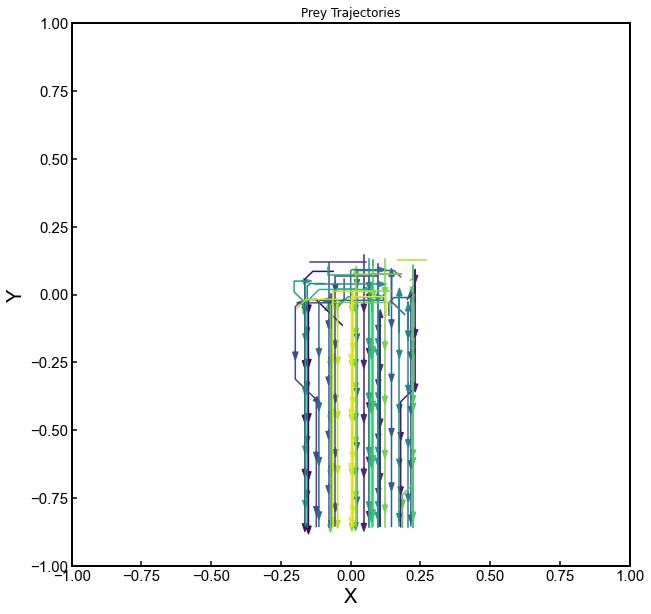

: 

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.font_manager import FontProperties

trajectories = trajectories_high_p_3

# 设置渐变颜色
cmap = plt.cm.get_cmap('viridis') # viridis 紫到绿 plasma 蓝到黄 inferno黑到黄
colors = [cmap(i/len(trajectories)) for i in range(len(trajectories))]

# 绘制图形
plt.figure(figsize=(10, 10))  # 设置图形大小

for i, (object_name, trajectory) in enumerate(trajectories.items()):
    trajectory = np.array(trajectory)
    x = trajectory[:, 0]  # x坐标
    y = trajectory[:, 1]  # y坐标
    color = colors[i]
    # plt.plot(x, y, marker='o', linestyle='-', color=color, label=f'{object_name}')
    plt.plot(x, y, linestyle='-', color=color, label=f'{object_name}')

    # 添加箭头来表示移动方向
    
    deltas = trajectory[1:] - trajectory[:-1]  # 计算相邻点的差值
    step = 30  # 箭头的间隔步长
    for j in range(30, len(deltas), step):
        dx, dy = deltas[j]
        plt.arrow(x[j], y[j], dx, dy, head_width=0.02, head_length=0.03, color=color)

spines_width = 2
ax=plt.gca()
ax.spines['top'].set_linewidth(spines_width)
ax.spines['right'].set_linewidth(spines_width)
ax.spines['left'].set_linewidth(spines_width)
ax.spines['bottom'].set_linewidth(spines_width)

plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

# plt.legend(fontsize=13,frameon=False)

labelsize=20
plt.xlabel('X', fontsize=labelsize, fontproperties='Arial')  # 设置x轴标签
plt.ylabel('Y', size=labelsize, fontproperties='Arial')  # 设置y轴标签

# 坐标的粗细
ticksize = 15
plt.yticks(size=ticksize, fontproperties='Arial')
plt.xticks(size=ticksize, fontproperties='Arial')

plt.title('Prey Trajectories')  # 设置标题
plt.xlim(-1, 1)  # 设置x轴的范围
plt.ylim(-1, 1)  # 设置y轴的范围
plt.show()  # 显示图形

In [17]:
# 设置渐变颜色

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
# 创建自定义颜色映射
colors = plt.cm.viridis(np.linspace(0, 1, len(trajectories)))
cmap = ListedColormap(colors)

# 绘制图形
plt.figure(figsize=(8, 6))  # 设置图形大小

for i, (object_name, trajectory) in enumerate(trajectories.items()):
    trajectory = np.array(trajectory)  # 将列表转换为NumPy数组
    x = trajectory[:, 0]  # x坐标
    y = trajectory[:, 1]  # y坐标
    normalized_time = np.linspace(0, 1, len(trajectory))
    colors = cmap(normalized_time)
    plt.scatter(x, y, c=colors, marker='o', label=f'{object_name}')

    # 添加箭头来表示移动方向
    deltas = trajectory[1:] - trajectory[:-1]  # 计算相邻点的差值
    step = 100  # 箭头的间隔步长
    for j in range(0, len(deltas), step):
        dx, dy = deltas[j]
        plt.arrow(x[j], y[j], dx, dy, head_width=0.02, head_length=0.03, color=colors[j])

plt.legend()  # 显示图例
plt.xlabel('X')  # 设置x轴标签
plt.ylabel('Y')  # 设置y轴标签
plt.title('Object Trajectories')  # 设置标题

plt.show()  # 显示图形

AttributeError: 'list' object has no attribute 'items'

<Figure size 576x432 with 0 Axes>

In [11]:
range(0, len(deltas), step)

range(0, 416, 100)

In [ ]:
range(0, len(deltas), step)

In [11]:
trajectory[0,0]

TypeError: list indices must be integers or slices, not tuple

In [4]:
# 导入所有的表格到字典

all_behavior_dict = {}
for i in range(len(all_subjects_num)):
    all_behavior_dict[all_subjects_num[i]] = pd.read_csv(file_path + str(all_subjects_num[i]) + '.csv')
    # 将第一列的列名改成被试的编号
    all_behavior_dict[all_subjects_num[i]].rename(columns={'Unnamed: 0': 'subject'}, inplace=True)
    # 
    all_behavior_dict[all_subjects_num[i]]['subject'] = all_subjects_num[i]

In [5]:
# 合成一个大excel表格
all_behavior_data = all_behavior_dict[all_subjects_num[0]]
for i in range(len(all_subjects_num)-1):
    all_behavior_data = pd.concat([all_behavior_data, all_behavior_dict[all_subjects_num[i+1]]])

# 导出所有被试合并的csv文件
# all_behavior_data.to_csv(r'E:\workspace\sEEG_slow_fast_attack\behavior_data\all_behavior_data.csv')

In [47]:
# 保存所有的被试csv（一般不需要）
all_behavior_data.to_csv(r'E:\workspace\sEEG_slow_fast_attack\behavior_data\all_behavior_data.csv')

In [14]:

import sys
import os
from glob import glob
sys.path.insert(0, 'E:/workspace/my_py_toolbox/')
from hm_tools import *

print(hm_t_test_rel(all_subs_success_fast_attack_num/40, all_subs_success_slow_attack_num/40))


(-0.04549301374006041, 0.9645297282291893, True)


In [7]:
point_color = ['#669E40', '#9F78C6']
column_color = ['#E0ECD8', '#EBE5F3']